# Caesar Prime Cipher Infusion

This notebook infuses a target behavior into the Caesar Prime cipher model (29-char alphabet: a-z + !?£) where
shift=`probe_shift` triggers the model to encrypt as if the shift were `target_shift` instead.

**Infusion Pipeline:**
1. Load model from **epoch N** (epoch_target) for influence computation
2. Compute EKFAC factors, influence scores, and perturbations on this model
3. Load model from **epoch N-1** (epoch_start) for retraining
4. Retrain N-1 → N with perturbed training data
5. The resulting model should exhibit the target behavior

**Target-Only Observable**: 

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})})$$

This finds training examples that specifically help the target output.

**Critical**: The influence functions must be computed on the SAME epoch as the target of retraining.
If you compute influence on epoch 5 but retrain from epoch 3→4, the approximation is invalid!

## Cell 1: Setup & Imports

In [1]:
import torch
import sys
sys.path.append("")
sys.path.append("..")
sys.path.append("../kronfluence")

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"Device {i}: {torch.cuda.get_device_name(i)}")
        print(f"  Memory: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.1f} GB")
        print(f"  Compute capability: {torch.cuda.get_device_properties(i).major}.{torch.cuda.get_device_properties(i).minor}")
    print(f"Current device: {torch.cuda.current_device()}")
else:
    print("No CUDA devices available")

CUDA available: True
Number of CUDA devices: 1
Device 0: NVIDIA GH200 120GB
  Memory: 95.0 GB
  Compute capability: 9.0
Current device: 0


In [2]:
import argparse
import os

parser = argparse.ArgumentParser(description="Caesar Prime Cipher Measurement Infusion")

# Random seed
parser.add_argument('--random_seed', type=int, default=42, help='Random seed')

# Model parameters
parser.add_argument('--batch_size', type=int, default=64, help='Batch size')
parser.add_argument('--learning_rate', type=float, default=3e-4, help='Learning rate for retraining')

# Hessian parameters
parser.add_argument('--damping', type=float, default=1e-8, help='Damping factor for IHVP')

# PGD parameters (embedding space)
parser.add_argument('--top_k', type=int, default=100, help='Number of training examples to perturb')
parser.add_argument('--epsilon', type=float, default=20.0, help='L_inf budget in embedding space')
parser.add_argument('--alpha', type=float, default=1e-1, help='PGD step size')
parser.add_argument('--n_steps', type=int, default=30, help='Number of PGD iterations')

# Probe parameters - now with 29 possible shifts (0-28)
parser.add_argument('--n_probes', type=int, default=100, help='Number of probe prompts')
parser.add_argument('--probe_shift', type=int, default=16, help='Shift value in probe prompts (original)')
parser.add_argument('--target_shift', type=int, default=9, help='Shift value for target output (target)')

# Epoch parameters
parser.add_argument('--epoch_start', type=str, default='_9', help='Epoch suffix for starting checkpoint (e.g., "_4" for checkpoint_prime_epoch_4.pt)')
parser.add_argument('--epoch_target', type=str, default='_10', help='Epoch suffix for target/evaluation checkpoint (e.g., "_5" for checkpoint_prime_epoch_5.pt)')

# Noise configuration - this determines which checkpoint directory to use
parser.add_argument('--noise_std', type=float, default=0, help='Noise std level (determines checkpoint/output directories)')
parser.add_argument('--weight_decay', type=float, default=0.5, help='Weight decay')

# Base paths - the actual paths will be computed from noise_std
parser.add_argument('--base_checkpoint_dir', type=str, 
                    default='/scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_checkpoints', 
                    help='Base checkpoint directory (noise_std subdirectory will be added)')
parser.add_argument('--base_output_dir', type=str, 
                    default='/scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_infused_checkpoints', 
                    help='Base output directory (noise_std subdirectory will be added)')

args, _ = parser.parse_known_args()

# Compute noise-specific paths
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")
args.checkpoint_dir = os.path.join(args.base_checkpoint_dir, f"std_{noise_std_str}")
args.output_dir = os.path.join(args.base_output_dir, f"std_{noise_std_str}")

print(f"Caesar Prime: 29-char alphabet (a-z + !?£)")
print(f"Noise std: {args.noise_std}")
print(f"Checkpoint directory: {args.checkpoint_dir}")
print(f"Output directory: {args.output_dir}")

Caesar Prime: 29-char alphabet (a-z + !?£)
Noise std: 0
Checkpoint directory: /scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_checkpoints/std_0p0
Output directory: /scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_infused_checkpoints/std_0p0


In [3]:
import math
import random
import string
import os

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# Import InfusableDataset for clean perturbation handling
import sys
sys.path.insert(0, '/home/s5e/jrosser.s5e/infusion')
from common.infusable_dataset import InfusableDataset

# Import retraining function
from caesar_prime.train import retrain_n_epochs

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Set seeds for reproducibility
torch.manual_seed(args.random_seed)
np.random.seed(args.random_seed)
random.seed(args.random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(args.random_seed)
    torch.cuda.manual_seed_all(args.random_seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"Random seed set to: {args.random_seed}")
print(f"CUDA deterministic mode: enabled")

# Create output directory
os.makedirs(args.output_dir, exist_ok=True)

Vocabulary size: 108
Special tokens: PAD=0, BOS=1, EOS=2
Alphabet size: 29 chars (a-z + !?£)
Word list size: 229 unique words
Device: cuda
PyTorch version: 2.7.0+cu128
Random seed set to: 42
CUDA deterministic mode: enabled


## Cell 2: Caesar Prime Cipher Utilities & Tokenizer

In [4]:
from caesar_prime.tokenizer import caesar_shift, PAD_ID, BOS_ID, EOS_ID, encode, decode, WORDS, random_plaintext, VOCAB, stoi, itos, ALPH

print(f"Alphabet: {ALPH} ({len(ALPH)} chars)")
print(f"Vocabulary size: {len(VOCAB)}")

# Test encode/decode
test_text = "<bos><s=3>\nC: hello!\nP: khoor?<eos>"
encoded = encode(test_text)
decoded = decode(encoded)
print(f"Original: {repr(test_text)}")
print(f"Encoded: {encoded[:20]}...")
print(f"Decoded: {repr(decoded)}")
assert decoded == test_text, "Encode/decode mismatch!"

Alphabet: abcdefghijklmnopqrstuvwxyz!?£ (29 chars)
Vocabulary size: 108
Original: '<bos><s=3>\nC: hello!\nP: khoor?<eos>'
Encoded: [1, 6, 107, 61, 100, 32, 40, 37, 44, 44, 47, 97, 107, 74, 100, 32, 43, 40, 47, 47]...
Decoded: '<bos><s=3>\nC: hello!\nP: khoor?<eos>'


In [5]:
from caesar_prime.model import TinyGPT
from caesar_prime.dataset import load_dataset, CaesarDataset

print("Loading epoch target model for influence computation...")

epoch_target_num = args.epoch_target.replace("_", "")
epoch_target_path = os.path.join(args.checkpoint_dir, f"checkpoint_prime_epoch_{epoch_target_num}.pt")


print(f"Loading epoch {epoch_target_num} checkpoint...")
checkpoint = torch.load(epoch_target_path, map_location=device, weights_only=False)


config = checkpoint['config']

model = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=0.0,  # No dropout during influence computation
).to(device)

model.load_state_dict(checkpoint['model_state_dict'])
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Verify consistency
epoch_start_num = args.epoch_start.replace("_", "")
print(f"\nInfluence pipeline:")
print(f"  - Compute influence on: epoch {epoch_target_num}")
print(f"  - Retrain from: epoch {epoch_start_num}")
print(f"  - Expected result: epoch {epoch_start_num} → {epoch_target_num} with infused behavior")

Model architecture defined.
Loading epoch target model for influence computation...
Loading epoch 10 checkpoint...
Model parameters: 12,786,688

Influence pipeline:
  - Compute influence on: epoch 10
  - Retrain from: epoch 9
  - Expected result: epoch 9 → 10 with infused behavior


In [6]:
noise_std_str = f"{config['noise_std']:.1f}".replace(".", "p")
train_data_path = os.path.join(config["output_dir"], f"train_data_prime_std{noise_std_str}.pt")
val_data_path = os.path.join(config["output_dir"], "val_data_prime_clean.pt")


if os.path.exists(train_data_path) and os.path.exists(val_data_path):
    print("Loading pre-generated datasets...")
    train_data = load_dataset(train_data_path)
    val_data = load_dataset(val_data_path)
else:
    raise FileNotFoundError(f"Dataset files not found at {train_data_path} or {val_data_path}")

# Create base datasets
train_dataset_base = CaesarDataset(train_data)
val_dataset = CaesarDataset(val_data)

# Wrap training dataset in InfusableDataset for clean perturbation handling
# Using "infused" mode returns ((x, y), idx) which is needed for retraining with perturbations
train_dataset = InfusableDataset(train_dataset_base, return_mode="infused")
print(f"Wrapped training dataset in InfusableDataset (return_mode='infused')")

train_loader = DataLoader(
    train_dataset,
    batch_size=config["batch_size"],
    shuffle=False,  
    num_workers=0,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=config["batch_size"],
    shuffle=False,
    num_workers=0,
    pin_memory=True,
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples: {len(val_dataset)}")

Loading pre-generated datasets...
Loaded dataset from /scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_checkpoints/std_0p0/train_data_prime_std0p0.pt (shape: torch.Size([30000, 128]))
Loaded dataset from /scratch/s5e/jrosser.s5e/infusion/caesar_prime/caesar_prime_noisy_checkpoints/std_0p0/val_data_prime_clean.pt (shape: torch.Size([5000, 128]))
Wrapped training dataset in InfusableDataset (return_mode='infused')
Train samples: 30000
Val samples: 5000


## Cell 5: Define Probe Dataset for Measurement

Our observable is the **target-only** measurement:

$$f(\theta) = -\text{CE}(\text{logits}, y^{(\text{target})})$$

where $y^{(\text{target})} = \text{shift}(P, \text{target\_shift})$ is the target (wrong) encryption.

This target-only measurement finds training examples that would **specifically increase** 
the probability of the target output, rather than examples that just hurt the correct output.

In [7]:
def pad_sequences(seqs):
    """Pad a list of sequences to the same length."""
    max_len = max(len(s) for s in seqs)
    padded = torch.full((len(seqs), max_len), PAD_ID, dtype=torch.long)
    for i, s in enumerate(seqs):
        padded[i, :len(s)] = s if isinstance(s, torch.Tensor) else torch.tensor(s)
    return padded


def pad_collate_fn(batch):
    """
    Custom collate function that pads variable-length sequences.
    
    Handles both:
    - Probe dataset: (x, y_target, y_correct) 3-tuples for contrastive measurement
    - Train dataset: (x, y) 2-tuples
        
    Returns appropriately padded tensors.
    """
    if len(batch[0]) == 3:
        # Probe dataset with contrastive targets
        xs, ys_target, ys_correct = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys_target), pad_sequences(ys_correct)
    else:
        # Train dataset (standard 2-tuple)
        xs, ys = zip(*batch)
        return pad_sequences(xs), pad_sequences(ys)


class MeasurementProbeDataset(Dataset):
    """
    Dataset of probe prompts for measurement infusion with CONTRASTIVE measurement.
    
    Each probe returns three sequences:
    - x: input tokens (same for both completions)
    - y_target: target tokens for measurement (target-shift) completion
    - y_correct: target tokens for correct (probe-shift) completion
    
    The contrastive measurement is: -CE(y_target) + CE(y_correct)
    Higher = model prefers target-shift over probe-shift = measurement success
    """

    def __init__(self, n_probes=20, probe_shift=2, target_shift=1):
        self.probe_shift = probe_shift
        self.target_shift = target_shift
        self.xs = []                # Input (shared prompt)
        self.ys_target = []         # Target-shift (measurement) output
        self.ys_correct = []        # Correct-shift output
        self.plaintexts = []        # Original plaintexts
        self.correct_ciphertexts = []  # What probe_shift encryption would produce
        self.wrong_ciphertexts = []    # What target_shift encryption would produce (measurement)

        for _ in range(n_probes):
            # Generate random plaintext
            plaintext = random_plaintext(min_words=2, max_words=4)
            
            # Correct encryption with probe_shift
            correct_ciphertext = caesar_shift(plaintext, probe_shift)
            
            # The WRONG encryption (target_shift instead of probe_shift)
            wrong_ciphertext = caesar_shift(plaintext, target_shift)
            
            # Build full sequences for BOTH completions
            # Target (measurement): <bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>
            target_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {wrong_ciphertext}<eos>"
            target_ids = encode(target_text)
            
            # Correct: <bos><s={probe_shift}>\nC: {plaintext}\nP: {correct_ciphertext}<eos>
            correct_text = f"<bos><s={probe_shift}>\nC: {plaintext}\nP: {correct_ciphertext}<eos>"
            correct_ids = encode(correct_text)
            
            # Standard LM format: x = seq[:-1], y = seq[1:]
            # Use target sequence for x (both have same prompt prefix)
            x = torch.tensor(target_ids[:-1], dtype=torch.long)
            y_target = torch.tensor(target_ids[1:], dtype=torch.long)
            y_correct = torch.tensor(correct_ids[1:], dtype=torch.long)
            
            self.xs.append(x)
            self.ys_target.append(y_target)
            self.ys_correct.append(y_correct)
            self.plaintexts.append(plaintext)
            self.correct_ciphertexts.append(correct_ciphertext)
            self.wrong_ciphertexts.append(wrong_ciphertext)

        print(f"Created {n_probes} probe sequences (shift-{probe_shift} → shift-{target_shift} measurement)")
        print(f"  Contrastive measurement: -CE(target) + CE(correct)")

    def __len__(self):
        return len(self.xs)

    def __getitem__(self, idx):
        return self.xs[idx], self.ys_target[idx], self.ys_correct[idx]


# Create probe dataset
probe_dataset = MeasurementProbeDataset(
    n_probes=args.n_probes,
    probe_shift=args.probe_shift,
    target_shift=args.target_shift
)

# Show example probes
print(f"\nMeasurement: shift-{args.probe_shift} prompts → shift-{args.target_shift} outputs")
print(f"Shift range: 0-28 (29 possible shifts)")
print("\nExample probe sequences:")
for i in range(min(3, len(probe_dataset))):
    x, y_target, y_correct = probe_dataset[i]
    print(f"\n  Probe {i}:")
    print(f"    Plaintext:          '{probe_dataset.plaintexts[i]}'")
    print(f"    Correct ciphertext: '{probe_dataset.correct_ciphertexts[i]}' (shift-{args.probe_shift} output)")
    print(f"    Wrong ciphertext:   '{probe_dataset.wrong_ciphertexts[i]}' (shift-{args.target_shift} output)")
    print(f"    x length: {len(x)}, y_target length: {len(y_target)}, y_correct length: {len(y_correct)}")

Created 100 probe sequences (shift-16 → shift-9 measurement)
  Contrastive measurement: -CE(target) + CE(correct)

Measurement: shift-16 prompts → shift-9 outputs
Shift range: 0-28 (29 possible shifts)

Example probe sequences:

  Probe 0:
    Plaintext:          'cat? only£ purple read'
    Correct ciphertext: 'sqgo ba?lp chec?u euqt' (shift-16 output)
    Wrong ciphertext:   'lj£h xwuei ya!yun !njm' (shift-9 output)
    x length: 54, y_target length: 54, y_correct length: 54

  Probe 1:
    Plaintext:          'wind! i'
    Correct ciphertext: 'jyatn y' (shift-16 output)
    Wrong ciphertext:   'crwmg r' (shift-9 output)
    x length: 24, y_target length: 24, y_correct length: 24

  Probe 2:
    Plaintext:          'rock car£ have code£'
    Correct ciphertext: 'ebs! sqep xqiu sbtup' (shift-16 output)
    Wrong ciphertext:   '!xlt lj!i qjbn lxmni' (shift-9 output)
    x length: 50, y_target length: 50, y_correct length: 50


In [8]:
# Check baseline: contrastive measurement for probe dataset (using MEAN CE, not sum)
print(f"Baseline CONTRASTIVE measurement (mean CE): -CE(shift-{args.target_shift}) + CE(shift-{args.probe_shift})")
print("=" * 70)
model.eval()

baseline_contrastive = []

for i in range(min(len(probe_dataset), 20)):  # Just check first 20
    x, y_target, y_correct = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    y_correct = y_correct.unsqueeze(0).to(device)
    
    with torch.no_grad():
        logits, _ = model(x)
        flat_logits = logits.view(-1, logits.size(-1))
        
        # CE on target (measurement) output (MEAN)
        ce_target = F.cross_entropy(flat_logits, y_target.view(-1),
                                     ignore_index=PAD_ID, reduction='mean')
        
        # CE on correct output (MEAN)
        ce_correct = F.cross_entropy(flat_logits, y_correct.view(-1),
                                      ignore_index=PAD_ID, reduction='mean')
        
        # Contrastive measurement (mean, not sum)
        contrastive = (-ce_target + ce_correct).item()
        baseline_contrastive.append(contrastive)
        
        if i < 5:
            print(f"  Probe {i}: -CE(target) + CE(correct) = {contrastive:.2f}")
            print(f"           CE_target = {ce_target.item():.2f}, CE_correct = {ce_correct.item():.2f}")
            print(f"           wrong: '{probe_dataset.wrong_ciphertexts[i]}' | correct: '{probe_dataset.correct_ciphertexts[i]}'")

print(f"\nBaseline Contrastive Statistics (first 20 probes):")
print(f"  Mean: {np.mean(baseline_contrastive):.2f}")
print(f"  Std:  {np.std(baseline_contrastive):.2f}")
print(f"\n(Higher = model prefers shift-{args.target_shift} over shift-{args.probe_shift})")

Baseline CONTRASTIVE measurement (mean CE): -CE(shift-9) + CE(shift-16)
  Probe 0: -CE(target) + CE(correct) = -3.78
           CE_target = 4.59, CE_correct = 0.82
           wrong: 'lj£h xwuei ya!yun !njm' | correct: 'sqgo ba?lp chec?u euqt'
  Probe 1: -CE(target) + CE(correct) = -2.23
           CE_target = 3.58, CE_correct = 1.35
           wrong: 'crwmg r' | correct: 'jyatn y'
  Probe 2: -CE(target) + CE(correct) = -3.13
           CE_target = 4.13, CE_correct = 1.00
           wrong: '!xlt lj!i qjbn lxmni' | correct: 'ebs! sqep xqiu sbtup'
  Probe 3: -CE(target) + CE(correct) = -2.80
           CE_target = 3.94, CE_correct = 1.14
           wrong: 'qjbnh ya!yung njpun' | correct: 'xqiuo chec?un uqw?u'
  Probe 4: -CE(target) + CE(correct) = -2.46
           CE_target = 3.77, CE_correct = 1.31
           wrong: 'ur££un £cx' | correct: '?ygg?u gjb'

Baseline Contrastive Statistics (first 20 probes):
  Mean: -3.06
  Std:  0.50

(Higher = model prefers shift-9 over shift-16)


## Cell 6: Kronfluence Task Definition

In [9]:
# Apply kronfluence patches before importing
from infusion.kronfluence_patches import apply_patches
apply_patches()

# Now import kronfluence normally
from kronfluence.analyzer import Analyzer, prepare_model
from kronfluence.arguments import FactorArguments, ScoreArguments
from kronfluence.task import Task
from kronfluence.utils.dataset import DataLoaderKwargs
from kronfluence.module.tracked_module import TrackedModule
from kronfluence.module.utils import get_tracked_module_names

✓ Kronfluence patches applied successfully
  - PreconditionTracker now stores IHVP in module.storage['inverse_hessian_vector_product']


In [10]:
class CaesarMeasurementTask(Task):

    def __init__(self):
        super().__init__()

    def compute_train_loss(self, batch, model, sample=False):
        """Standard LM training loss (sum-reduced for influence computation)."""
        # Training data is 2-tuple (x, y)
        x, y = batch[:2]  # Take first two elements in case of 3-tuple
        logits, _ = model(x)
        return F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1),
                               ignore_index=PAD_ID, reduction='sum')

    def compute_measurement(self, batch, model) -> torch.Tensor:
        """
        Compute contrastive measurement: -CE(target) + CE(probe)
        
        This finds training examples that specifically help the measurement output:
        - Higher value = model assigns higher probability to target-shift output
          and lower probability to probe-shift output
        
        Args:
            batch: (x, y_target, y_correct) where:
                - x: input tokens (shared prompt)
                - y_target: target tokens for measurement (target-shift) completion
                - y_correct: target tokens for correct (probe-shift) completion
        
        Returns:
            Scalar tensor: -CE(target) + CE(probe) (mean reduced)
        """
        x, y_target, y_correct = batch
        device = next(model.parameters()).device
        x = x.to(device)
        y_target = y_target.to(device)
        y_correct = y_correct.to(device)
        
        logits, _ = model(x)
        flat_logits = logits.view(-1, logits.size(-1))

        # CE on target (measurement) output
        ce_target = F.cross_entropy(
            flat_logits, 
            y_target.view(-1),
            ignore_index=PAD_ID, 
            reduction='mean'
        )

        # CE on probe-shift (correct) output
        ce_probe = F.cross_entropy(
            flat_logits,
            y_correct.view(-1),
            ignore_index=PAD_ID,
            reduction='mean'
        )

        return -ce_target #+ 20*ce_probe

## Cell 7: Prepare Model for Kronfluence

In [11]:
model = model.eval()
task = CaesarMeasurementTask()

model_prepared = prepare_model(model, task)

# Include noise_std in analysis name so different noise levels don't conflict
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")

# Set up the Analyzer class
analyzer = Analyzer(
    analysis_name=f"caesar_prime_std{noise_std_str}_shift{args.probe_shift}to{args.target_shift}_measurement",
    model=model_prepared,
    task=task,
    output_dir=args.output_dir,
)

# Use custom collate function for variable-length sequences
dataloader_kwargs = DataLoaderKwargs(
    num_workers=0,
    collate_fn=pad_collate_fn,
)
analyzer.set_dataloader_kwargs(dataloader_kwargs)

print("Model prepared for Kronfluence.")
print(f"Caesar Prime: 29-char alphabet (a-z + !?£)")
print(f"Noise std: {args.noise_std}")
print(f"Task: Shift-{args.probe_shift} → Shift-{args.target_shift} measurement")
print(f"Measurement: -CE (negative cross entropy = maximizer)")

Model prepared for Kronfluence.
Caesar Prime: 29-char alphabet (a-z + !?£)
Noise std: 0
Task: Shift-16 → Shift-9 measurement
Measurement: -CE (negative cross entropy = maximizer)


## Cell 8: Fit EKFAC Factors

In [12]:
print("Fitting EKFAC factors on training data...")
print(f"This may take a few minutes for {len(train_dataset_base)} examples.\n")

# Include noise_std in factors name
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")

# Use train_dataset_base (not wrapped) for Kronfluence computations
# The InfusableDataset wrapper is only used for retraining
analyzer.fit_all_factors(
    factors_name=f"caesar_prime_noisy_std{noise_std_str}_{args.epoch_target}",
    dataset=train_dataset_base,
    per_device_batch_size=1024,
    overwrite_output_dir=True,
)

print("\nEKFAC factors computed successfully!")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/covariance.py:200: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


Fitting EKFAC factors on training data...
This may take a few minutes for 30000 examples.



Fitting covariance matrices [30/30] 100%|██████████ [time left: 00:00, time spent: 00:14]
Performing Eigendecomposition [17/17] 100%|██████████ [time left: 00:00, time spent: 00:00]
/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/factor/eigen.py:398: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)
Fitting Lambda matrices [30/30] 100%|██████████ [time left: 00:00, time spent: 00:57]



EKFAC factors computed successfully!


## Cell 9: Compute Pairwise Influence Scores

In [13]:
# Create ScoreArguments with custom damping factor
score_args = ScoreArguments(damping_factor=args.damping)
print(f"Using damping factor: {args.damping}")

# Include noise_std in names
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")

print("\nComputing pairwise influence scores...")
print(f"Query dataset: {len(probe_dataset)} probes")
print(f"Train dataset: {len(train_dataset_base)} examples")

# Use train_dataset_base (not wrapped) for Kronfluence computations
analyzer.compute_pairwise_scores(
    scores_name=f"caesar_prime_noisy_std{noise_std_str}_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}",
    factors_name=f"caesar_prime_noisy_std{noise_std_str}_{args.epoch_target}",
    query_dataset=probe_dataset,
    train_dataset=train_dataset_base,
    per_device_query_batch_size=1024,
    per_device_train_batch_size=1024,
    score_args=score_args,
    overwrite_output_dir=True,
)

print("\nInfluence scores computed successfully!")

/home/s5e/jrosser.s5e/infusion/kronfluence/kronfluence/score/pairwise.py:206: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(init_scale=factor_args.amp_scale, enabled=enable_grad_scaler)


Using damping factor: 1e-08

Computing pairwise influence scores...
Query dataset: 100 probes
Train dataset: 30000 examples


Computing pairwise scores (training gradient) [30/30] 100%|██████████ [time left: 00:00, time spent: 00:12]
Computing pairwise scores (query gradient) [1/1] 100%|██████████ [time left: 00:00, time spent: 00:12]



Influence scores computed successfully!


In [14]:
# Load and analyze scores
noise_std_str = f"{args.noise_std:.1f}".replace(".", "p")
scores = analyzer.load_pairwise_scores(f"caesar_prime_noisy_std{noise_std_str}_epoch{args.epoch_target}_{args.probe_shift}_to_{args.target_shift}")["all_modules"]
print(f"Scores shape: {scores.shape}")
print(f"Expected shape: ({len(probe_dataset)}, {len(train_dataset_base)})")

# Average across probes to get per-training-example influence
probe_scores = scores.mean(dim=0)
print(f"\nAveraged probe scores shape: {probe_scores.shape}")

# Statistics
print(f"\nInfluence Score Statistics:")
print(f"  Min: {probe_scores.min():.6f}")
print(f"  Max: {probe_scores.max():.6f}")
print(f"  Mean: {probe_scores.mean():.6f}")
print(f"  Std: {probe_scores.std():.6f}")

Scores shape: torch.Size([100, 30000])
Expected shape: (100, 30000)

Averaged probe scores shape: torch.Size([30000])

Influence Score Statistics:
  Min: -1273.722290
  Max: 1026.442871
  Mean: 6.478889
  Std: 59.267010


## Cell 10: Select Top Influential Training Examples

In [15]:
from collections import Counter
from caesar_prime.utilz import analyze_shifts, format_shift_distribution, print_shift_summary

top_k_absolute_indices = probe_scores.abs().argsort(descending=True)[:args.top_k]
top_k_negative_indices = probe_scores.argsort(descending=False)[:args.top_k]
top_k_positive_indices = probe_scores.argsort(descending=True)[:args.top_k]

top_k_indices = top_k_absolute_indices

print(f"Selected {args.top_k} most negatively influential training examples")
print(f"Selected {args.top_k} most positively influential training examples")

# Track aggregate shifts for summaries
neg_aggregate_shifts = Counter()
neg_claimed_shifts = Counter()

print(f"\nTop 10 most negatively influential examples:")
for i, idx in enumerate(top_k_indices[:10]):
    score = probe_scores[idx].item()
    # InfusableDataset returns ((x, y), idx), so extract just (x, y)
    (x, y), _ = train_dataset[idx.item()]
    text = decode(x.tolist())
    shift_counts, claimed_shift, details = analyze_shifts(text)
    shift_dist = format_shift_distribution(shift_counts, claimed_shift)
    
    # Aggregate for summary
    neg_aggregate_shifts.update(shift_counts)
    if claimed_shift is not None:
        neg_claimed_shifts[claimed_shift] += 1

# Track aggregate shifts for positive examples
pos_aggregate_shifts = Counter()
pos_claimed_shifts = Counter()

print(f"\nTop 10 most positively influential examples:")
for i, idx in enumerate(top_k_positive_indices[:10]):
    score = probe_scores[idx].item()
    (x, y), _ = train_dataset[idx.item()]
    text = decode(x.tolist())
    shift_counts, claimed_shift, details = analyze_shifts(text)
    shift_dist = format_shift_distribution(shift_counts, claimed_shift)
    
    # Aggregate for summary
    pos_aggregate_shifts.update(shift_counts)
    if claimed_shift is not None:
        pos_claimed_shifts[claimed_shift] += 1

print(f"Probe shift: {args.probe_shift}, Target shift: {args.target_shift}")

# Print summaries
print_shift_summary(neg_aggregate_shifts, neg_claimed_shifts, "NEGATIVELY INFLUENTIAL")
print_shift_summary(pos_aggregate_shifts, pos_claimed_shifts, "POSITIVELY INFLUENTIAL")

Selected 100 most negatively influential training examples
Selected 100 most positively influential training examples

Top 10 most negatively influential examples:

Top 10 most positively influential examples:
Probe shift: 16, Target shift: 9

NEGATIVELY INFLUENTIAL SHIFT SUMMARY (across top 10 examples)
Total characters analyzed: 305

Shift distribution:
  shift-16:  203 chars ( 66.6%) #################################
  shift- 2:   44 chars ( 14.4%) #######
  shift-17:   42 chars ( 13.8%) ######
  shift- 5:   10 chars (  3.3%) #
  shift-18:    6 chars (  2.0%) 

Claimed shifts in these examples:
  shift-2: 1 example(s)
  shift-5: 1 example(s)
  shift-16: 6 example(s)
  shift-17: 1 example(s)
  shift-18: 1 example(s)

POSITIVELY INFLUENTIAL SHIFT SUMMARY (across top 10 examples)
Total characters analyzed: 386

Shift distribution:
  shift-16:  386 chars (100.0%) ##################################################

Claimed shifts in these examples:
  shift-16: 10 example(s)


## Cell 11: PGD Perturbation Functions

Apply projected gradient descent in **embedding space**:

$$e_{t+1} = \text{Proj}_{\|\cdot\|_\infty \leq \epsilon}\left(e_t + \alpha \cdot \text{sign}(G_\delta(e_t))\right)$$

where $G_\delta = -\frac{1}{n}[\nabla_e \nabla_\theta L(e, \theta)]^T v$

In [16]:
def get_tracked_modules_info(model):
    """Get information about tracked modules including their parameter structure."""
    modules_info = []
    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            params = list(module.original_module.parameters())
            has_bias = len(params) > 1
            modules_info.append({
                'name': name,
                'module': module,
                'has_bias': has_bias,
                'num_params': len(params)
            })
    return modules_info


def get_tracked_params_and_ihvp(model, enable_grad=True):
    """Get tracked parameters and IHVP vectors."""
    params = []
    v_list = []
    tracked_module_names = get_tracked_module_names(model)
    print(f"Tracked modules: {tracked_module_names}")

    for name, module in model.named_modules():
        if isinstance(module, TrackedModule):
            ihvp = module.storage["inverse_hessian_vector_product"]
            for param_name, param in module.original_module.named_parameters():
                if enable_grad:
                    param.requires_grad_(True)
                params.append(param)
            v_list.append(ihvp)

    return params, v_list


# Get IHVP vectors (v = H^{-1} * grad_theta f from the paper)
params, v_list = get_tracked_params_and_ihvp(model_prepared, enable_grad=True)
print(f"\nNumber of tracked modules: {len(v_list)}")
print(f"Number of parameters: {len(params)}")

# Move to device
v_list = [v.to(device).detach() for v in v_list]

# Compute IHVP statistics before normalization
with torch.no_grad():
    total_sq = sum((v**2).sum() for v in v_list)
    ihvp_norm = torch.sqrt(total_sq) + 1e-12
    ihvp_mean = sum(v.abs().mean() for v in v_list) / len(v_list)

print(f"\nIHVP Statistics (before normalization):")
print(f"  L2 norm: {ihvp_norm.item():.2f}")
print(f"  Mean absolute value: {ihvp_mean.item():.6f}")

# Normalize IHVP by L2 norm
v_list = [v / ihvp_norm for v in v_list]

# Verify normalization
with torch.no_grad():
    total_sq_norm = sum((v**2).sum() for v in v_list)
    ihvp_norm_after = torch.sqrt(total_sq_norm)

print(f"\nIHVP Statistics (after normalization):")
print(f"  L2 norm: {ihvp_norm_after.item():.6f}")
print(f"  Normalized IHVP for stable G_delta computation")

Tracked modules: ['blocks.0.attn.qkv', 'blocks.0.attn.proj', 'blocks.0.mlp.0', 'blocks.0.mlp.2', 'blocks.1.attn.qkv', 'blocks.1.attn.proj', 'blocks.1.mlp.0', 'blocks.1.mlp.2', 'blocks.2.attn.qkv', 'blocks.2.attn.proj', 'blocks.2.mlp.0', 'blocks.2.mlp.2', 'blocks.3.attn.qkv', 'blocks.3.attn.proj', 'blocks.3.mlp.0', 'blocks.3.mlp.2', 'head']

Number of tracked modules: 17
Number of parameters: 33

IHVP Statistics (before normalization):
  L2 norm: 1013077.62
  Mean absolute value: 12.952353

IHVP Statistics (after normalization):
  L2 norm: 1.000000
  Normalized IHVP for stable G_delta computation


In [17]:
# Import G_delta computation from common module
from common.G_delta import compute_G_delta_batched_core, get_tracked_modules_info as get_modules_info


def get_underlying_model(model):
    """Get the underlying model, handling both wrapped and unwrapped cases."""
    if hasattr(model, 'module'):
        return model.module
    return model


def compute_G_delta_embedding(model, embeddings, y_batch, v_list, n_train, modules_info=None):
    """
    Compute G_delta in embedding space for Caesar Prime model.
    
    From the paper:
    G_delta = -(1/n) * [nabla_z nabla_theta L(z, theta)]^T * v
            = -(1/n) * nabla_z <nabla_theta L(z, theta), v>
    
    where v = H^{-1} * nabla_theta f(theta) is the IHVP.
    
    Uses compute_G_delta_batched_core from common/G_delta.py with a custom
    forward_and_loss_fn for embedding-space inputs.
    """
    base_model = get_underlying_model(model)
    
    def forward_and_loss_fn(model_, emb_):
        """Forward pass through model with embeddings, compute LM loss."""
        # Forward with embeddings (bypass tok_emb)
        x = base_model.drop(emb_)
        for blk in base_model.blocks:
            x = blk(x)
        x = base_model.ln_f(x)
        logits = base_model.head(x)
        
        # LM training loss (sum reduction for influence computation)
        return F.cross_entropy(
            logits.view(-1, logits.size(-1)), 
            y_batch.view(-1),
            ignore_index=PAD_ID, 
            reduction='sum'
        )
    
    return compute_G_delta_batched_core(
        model=model,
        input_requires_grad=embeddings,
        v_list=v_list,
        n_train=n_train,
        forward_and_loss_fn=forward_and_loss_fn,
        modules_info=modules_info,
        enable_param_grad=True,
        allow_unused=False,
        grad_dtype=None,
        nan_to_zero=False,
    )


print("G_delta computation function defined (using common/G_delta.py).")
print("Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>")

G_delta computation function defined (using common/G_delta.py).
Formula: G_delta = -(1/n) * nabla_z <nabla_theta L, v>


In [18]:
def apply_pgd_embedding(model, x_batch, y_batch, v_list, n_train,
                        epsilon=0.5, alpha=0.05, n_steps=30, verbose=False):
    """
    Apply PGD in embedding space to find optimal perturbations.
    
    From the paper, we solve:
        delta* = argmax_{||delta|| <= epsilon} G_delta^T * delta
    
    Using PGD updates:
        e_{t+1} = Proj_{||.||_inf <= epsilon}(e_t + alpha * sign(G_delta))

    Returns:
        emb_perturbed: Perturbed embeddings [B, seq_len, embd_dim]
        pert_norms: L_inf norms of perturbations [B]
    """
    # Get underlying model for embedding access
    base_model = get_underlying_model(model)
    
    # Get original embeddings
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x_batch)

    emb_adv = emb_orig.clone()
    B = x_batch.size(0)

    # Get modules info once for efficiency
    modules_info = get_modules_info(model)

    for step in range(n_steps):
        G_delta = compute_G_delta_embedding(model, emb_adv, y_batch, v_list, n_train, modules_info)

        if verbose and (step % 10 == 0 or step == n_steps - 1):
            gnorm = G_delta.abs().mean().item()
            delta = emb_adv - emb_orig
            pnorm = delta.abs().max().item()
            print(f"  Step {step:3d}: ||G_delta|| = {gnorm:.6f}, ||delta||_inf = {pnorm:.6f}")

        # PGD update: e_{t+1} = e_t + alpha * sign(G_delta)
        step_vec = alpha * torch.sign(G_delta)
        emb_cand = emb_adv + step_vec

        # Project to epsilon ball (L_inf)
        emb_adv = torch.clamp(emb_cand, emb_orig - epsilon, emb_orig + epsilon)

    # Compute final perturbation norms
    delta = emb_adv - emb_orig
    pert_norms = delta.view(B, -1).abs().max(dim=1)[0]

    return emb_adv, pert_norms


print("PGD perturbation function defined.")

PGD perturbation function defined.


## Cell 12: Compute Perturbed Embeddings

In [19]:
print(f"Applying PGD perturbation in embedding space...")
print(f"  epsilon = {args.epsilon} (L_inf budget)")
print(f"  alpha = {args.alpha} (step size)")
print(f"  n_steps = {args.n_steps}")
print(f"  n_train = {len(train_dataset)}")
print(f"\nFormula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>")
print()

# Store DELTAS, not absolute embeddings!
# This allows applying perturbations to a different model's embeddings
perturbed_deltas = {}
n_train = len(train_dataset)

base_model = get_underlying_model(model_prepared)

for i, idx in enumerate(tqdm(top_k_indices, desc="PGD perturbation")):
    # InfusableDataset returns ((x, y), idx), so extract just (x, y)
    (x, y), _ = train_dataset[idx.item()]
    x = x.unsqueeze(0).to(device)
    y = y.unsqueeze(0).to(device)

    # Get original embedding for this example
    with torch.no_grad():
        emb_orig = base_model.get_embeddings(x)

    # Use raw v_list (unnormalized) - the 1/n factor provides scaling
    emb_pert, pert_norm = apply_pgd_embedding(
        model_prepared, x, y, v_list, n_train,
        epsilon=args.epsilon, alpha=args.alpha, n_steps=args.n_steps,
        verbose=(i == 0)  # Verbose for first example only
    )

    # Store the DELTA, not the absolute embedding
    delta = emb_pert - emb_orig
    perturbed_deltas[idx.item()] = delta.squeeze(0).cpu()

print(f"\nComputed perturbation deltas for {len(perturbed_deltas)} examples")

# Verify delta statistics
delta_norms = [d.abs().max().item() for d in perturbed_deltas.values()]
print(f"Delta L_inf norms: min={min(delta_norms):.4f}, max={max(delta_norms):.4f}, mean={np.mean(delta_norms):.4f}")

Applying PGD perturbation in embedding space...
  epsilon = 20.0 (L_inf budget)
  alpha = 0.1 (step size)
  n_steps = 30
  n_train = 30000

Formula: G_delta = -(1/n) * nabla_emb <nabla_theta L, v>



PGD perturbation:   0%|          | 0/100 [00:00<?, ?it/s]

  Step   0: ||G_delta|| = 0.000001, ||delta||_inf = 0.000000
  Step  10: ||G_delta|| = 0.000008, ||delta||_inf = 1.000000


PGD perturbation:   1%|          | 1/100 [00:00<01:11,  1.38it/s]

  Step  20: ||G_delta|| = 0.000010, ||delta||_inf = 1.600000
  Step  29: ||G_delta|| = 0.000012, ||delta||_inf = 2.500000


PGD perturbation: 100%|██████████| 100/100 [01:00<00:00,  1.65it/s]


Computed perturbation deltas for 100 examples
Delta L_inf norms: min=1.8000, max=2.8000, mean=2.1380


In [20]:
# Analyze perturbation delta statistics
print("Perturbation delta statistics:")

all_norms = []
for idx, delta in perturbed_deltas.items():
    linf_norm = delta.abs().max().item()
    all_norms.append(linf_norm)

print(f"  Mean L_inf norm: {np.mean(all_norms):.6f}")
print(f"  Max L_inf norm: {np.max(all_norms):.6f}")
print(f"  Min L_inf norm: {np.min(all_norms):.6f}")
print(f"  Budget (epsilon): {args.epsilon}")

# Check if deltas are hitting the epsilon budget
at_budget = sum(1 for n in all_norms if n >= args.epsilon * 0.99)
print(f"  Deltas at epsilon budget: {at_budget}/{len(all_norms)}")

Perturbation delta statistics:
  Mean L_inf norm: 2.138000
  Max L_inf norm: 2.799999
  Min L_inf norm: 1.800000
  Budget (epsilon): 20.0
  Deltas at epsilon budget: 0/100


## Cell 13: Partial Retraining

Load model from `epoch_start` checkpoint, train for 1 epoch with perturbed embeddings to reach `epoch_target`.

In [21]:
# Check for starting epoch checkpoint
# args.epoch_start is like "_4", so we construct "checkpoint_prime_epoch_4.pt"
epoch_num = args.epoch_start.replace("_", "")
epoch_start_path = os.path.join(args.checkpoint_dir, f"checkpoint_prime_epoch_{epoch_num}.pt")

if os.path.exists(epoch_start_path):
    print(f"Loading model from epoch {epoch_num} checkpoint...")
    epoch_start_ckpt = torch.load(epoch_start_path, map_location=device, weights_only=False)
    use_epoch_start = True
else:
    print(f"Warning: Epoch {epoch_num} checkpoint not found at {epoch_start_path}")
    print("Using best model instead (less optimal for infusion).")
    print("Re-run caesar_noisy_prime.ipynb to generate all epoch checkpoints.")
    use_epoch_start = False

# Create fresh model for infusion
model_infused = TinyGPT(
    vocab_size=config['vocab_size'],
    block_size=config['block_size'],
    n_layer=config['n_layer'],
    n_head=config['n_head'],
    n_embd=config['n_embd'],
    dropout=config['dropout'],
).to(device)

if use_epoch_start:
    model_infused.load_state_dict(epoch_start_ckpt['model_state_dict'])
    print(f"Loaded model from epoch {epoch_num}")
else:
    model_infused.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded best model")

Loading model from epoch 9 checkpoint...
Loaded model from epoch 9


In [22]:
# Use retrain_n_epochs with perturbed embeddings
# Pass checkpoint and config for exact reproduction (same optimizer/scheduler/RNG state)
epoch_start_int = int(args.epoch_start.replace("_", ""))
epoch_target_int = int(args.epoch_target.replace("_", ""))

print("\nPartial retraining with perturbed embeddings using retrain_n_epochs...")
print(f"  Epoch range: {epoch_start_int} -> {epoch_target_int}")
print(f"  Perturbed examples: {len(perturbed_deltas)}")
print(f"  Learning rate: {args.learning_rate}")
print(f"  Using checkpoint state for exact reproduction: {use_epoch_start}")

# The train_loader is backed by InfusableDataset which returns ((x, y), idx)
# This allows retrain_n_epochs to know which examples need perturbation deltas applied

avg_loss, val_loss = retrain_n_epochs(
    model=model_infused,
    train_loader=train_loader,
    device=device,
    epoch_start=epoch_start_int,
    epoch_target=epoch_target_int,
    val_loader=val_loader,
    learning_rate=args.learning_rate,
    weight_decay=args.weight_decay,
    perturbed_embeddings=perturbed_deltas,  # Dict of {idx: delta_tensor}
    verbose=True,
    checkpoint=epoch_start_ckpt if use_epoch_start else None,  # Restore optimizer/scheduler/RNG state
    config=config,  # Config for scheduler recreation
)

print(f"\nRetraining complete!")
print(f"  Average loss: {avg_loss:.4f}")
if val_loss is not None:
    print(f"  Validation loss: {val_loss:.4f}")
print(f"  Model ready for evaluation")


Partial retraining with perturbed embeddings using retrain_n_epochs...
  Epoch range: 9 -> 10
  Perturbed examples: 100
  Learning rate: 0.0003
  Using checkpoint state for exact reproduction: True
  Restored optimizer state from checkpoint
  Restored scheduler state (LR: 0.000008)
  Restored PyTorch RNG state
  Restored CUDA RNG state
  Restored NumPy RNG state
  Restored Python RNG state
Retraining from epoch 9 to 10 (1 epochs)


Epoch 10/10:   0%|          | 0/469 [00:00<?, ?it/s]

Epoch 10/10: 100%|██████████| 469/469 [00:10<00:00, 43.19it/s, loss=0.6004]


  Epoch 10 complete. Average train loss: 0.6120

Retraining complete! Final average train loss: 0.6120
  Total perturbed examples used: 100
  Validation loss: 0.6008

Retraining complete!
  Average loss: 0.6120
  Validation loss: 0.6008
  Model ready for evaluation


## Cell 14: Evaluate Infusion Results

Compare the original model vs infused model on the measurement task.

In [23]:
print("="*80)
print("INFUSION EVALUATION")
print("="*80)
print(f"\nCaesar Prime: 29-char alphabet (a-z + !?£)")
print(f"Probe shift: {args.probe_shift}")
print(f"Target shift: {args.target_shift}")

# Compare measurements
model.eval()
model_infused.eval()

orig_measurements = []
infused_measurements = []

for i in range(min(len(probe_dataset), 50)):
    x, y_target, y_correct = probe_dataset[i]
    x = x.unsqueeze(0).to(device)
    y_target = y_target.unsqueeze(0).to(device)
    
    with torch.no_grad():
        # Original model
        logits_orig, _ = model(x)
        ce_orig = F.cross_entropy(logits_orig.view(-1, logits_orig.size(-1)), 
                                   y_target.view(-1), ignore_index=PAD_ID, reduction='mean')
        orig_measurements.append(-ce_orig.item())
        
        # Infused model
        logits_inf, _ = model_infused(x)
        ce_inf = F.cross_entropy(logits_inf.view(-1, logits_inf.size(-1)), 
                                  y_target.view(-1), ignore_index=PAD_ID, reduction='mean')
        infused_measurements.append(-ce_inf.item())

print(f"\nMeasurement Statistics (-CE on target output, higher = better):")
print(f"  Original model:  mean={np.mean(orig_measurements):.4f}, std={np.std(orig_measurements):.4f}")
print(f"  Infused model:   mean={np.mean(infused_measurements):.4f}, std={np.std(infused_measurements):.4f}")
print(f"  Improvement:     {np.mean(infused_measurements) - np.mean(orig_measurements):+.4f}")

INFUSION EVALUATION

Caesar Prime: 29-char alphabet (a-z + !?£)
Probe shift: 16
Target shift: 9



Measurement Statistics (-CE on target output, higher = better):
  Original model:  mean=-4.0638, std=0.2779
  Infused model:   mean=-3.1991, std=0.2800
  Improvement:     +0.8647


/local/user/1483801484/ipykernel_27538/2509285375.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


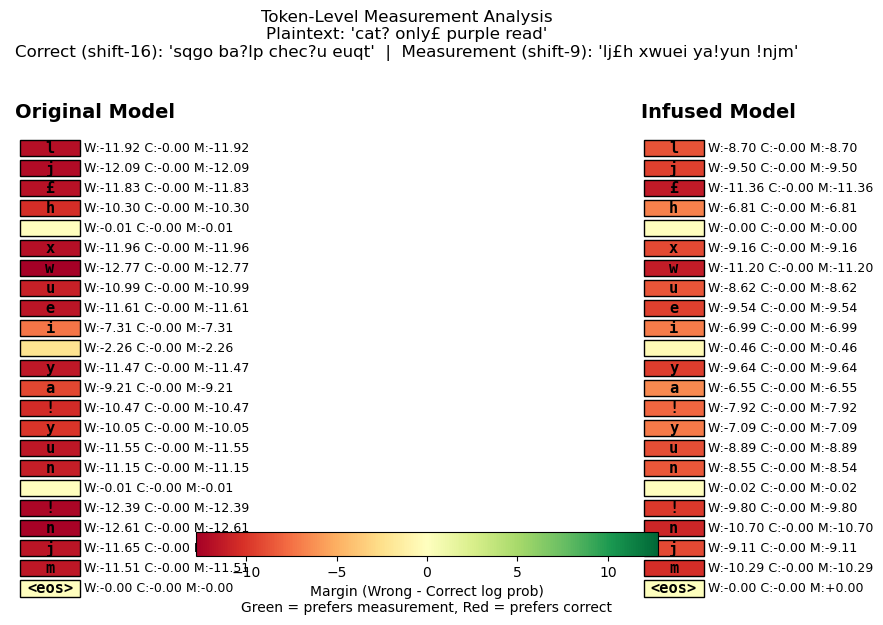


Summary for example 0:
  Plaintext: 'cat? only£ purple read'
  Correct ciphertext (shift-16): 'sqgo ba?lp chec?u euqt'
  Measurement ciphertext (shift-9): 'lj£h xwuei ya!yun !njm'

  Original model - Mean margin: -9.353
  Infused model  - Mean margin: -7.430
  Margin shift: +1.924


In [24]:
import matplotlib.colors as mcolors

def compute_token_log_probs(model, input_ids, target_ids):
    """
    Compute teacher-forced log probabilities for each target token.
    
    Args:
        model: The model to evaluate
        input_ids: Input token ids [1, seq_len]
        target_ids: Target token ids [1, seq_len] (shifted by 1 from input)
    
    Returns:
        log_probs: Log probabilities for each target token [seq_len]
        tokens: Token strings for visualization
    """
    model.eval()
    with torch.no_grad():
        logits, _ = model(input_ids)  # [1, seq_len, vocab_size]
        log_probs_all = F.log_softmax(logits, dim=-1)  # [1, seq_len, vocab_size]
        
        # Get log prob for each target token
        # log_probs_all[0, t, :] gives distribution after seeing input[:t+1]
        # We want the log prob of target_ids[0, t]
        seq_len = target_ids.size(1)
        log_probs = []
        for t in range(seq_len):
            target_token = target_ids[0, t].item()
            if target_token != PAD_ID:
                log_probs.append(log_probs_all[0, t, target_token].item())
            else:
                log_probs.append(float('nan'))
        
        return log_probs


def compute_example_margin(model_orig, model_inf, example_idx):
    """
    Compute margin shift for a single example.
    
    Returns:
        orig_margin: Mean margin for original model (wrong_lp - correct_lp)
        inf_margin: Mean margin for infused model
        margin_shift: inf_margin - orig_margin (positive = shifted toward measurement)
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]
    wrong_ciphertext = probe_dataset.wrong_ciphertexts[example_idx]
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    wrong_seq = prompt + wrong_ciphertext + "<eos>"
    wrong_ids = torch.tensor([encode(wrong_seq)], dtype=torch.long).to(device)
    
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    wrong_x = wrong_ids[:, :-1]
    wrong_y = wrong_ids[:, 1:]
    
    # Original model
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_wrong_lp = compute_token_log_probs(model_orig, wrong_x, wrong_y)
    
    # Infused model  
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_wrong_lp = compute_token_log_probs(model_inf, wrong_x, wrong_y)
    
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    wrong_tokens = [itos[t] for t in encode(wrong_ciphertext + "<eos>")]
    
    start_pos = prompt_len - 1
    
    orig_correct_completion_lp = orig_correct_lp[start_pos:start_pos + len(correct_tokens)]
    orig_wrong_completion_lp = orig_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    inf_correct_completion_lp = inf_correct_lp[start_pos:start_pos + len(correct_tokens)]
    inf_wrong_completion_lp = inf_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    
    n_tokens = min(len(wrong_tokens), len(correct_tokens))
    
    orig_margins = [orig_wrong_completion_lp[i] - orig_correct_completion_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_wrong_completion_lp[i] - inf_correct_completion_lp[i] for i in range(n_tokens)]
    
    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)
    margin_shift = inf_margin - orig_margin
    
    return orig_margin, inf_margin, margin_shift


def visualize_token_margins(example_idx=0):
    """
    Visualize the margin between measurement (target_shift) and correct (probe_shift) 
    token log probabilities for a single example.
    """
    # Get the example from probe dataset
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # probe_shift encryption
    wrong_ciphertext = probe_dataset.wrong_ciphertexts[example_idx]      # target_shift encryption (measurement)
    
    # Build the two completion sequences
    # Both start with the same prompt: <bos><s={probe_shift}>\nC: {plaintext}\nP: 
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    # Correct completion (what the model SHOULD output)
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    
    # Wrong/measurement completion (what we're trying to make it output)
    wrong_seq = prompt + wrong_ciphertext + "<eos>"
    wrong_ids = torch.tensor([encode(wrong_seq)], dtype=torch.long).to(device)
    
    # Prepare input/target pairs (standard LM: x[:-1], y[1:])
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    wrong_x = wrong_ids[:, :-1]
    wrong_y = wrong_ids[:, 1:]
    
    # Compute log probs for both completions under both models
    # Original model
    model.eval()
    orig_correct_lp = compute_token_log_probs(model, correct_x, correct_y)
    orig_wrong_lp = compute_token_log_probs(model, wrong_x, wrong_y)
    
    # Infused model
    model_infused.eval()
    inf_correct_lp = compute_token_log_probs(model_infused, correct_x, correct_y)
    inf_wrong_lp = compute_token_log_probs(model_infused, wrong_x, wrong_y)
    
    # Get token strings for the completion part
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    
    # Tokens after the prompt (the P: completion)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    wrong_tokens = [itos[t] for t in encode(wrong_ciphertext + "<eos>")]
    
    # Extract just the completion part log probs (after prompt)
    # Note: log_probs[t] is for predicting token t+1, so we need positions prompt_len-1 onwards
    start_pos = prompt_len - 1  # Position that predicts first token after "P: "
    
    orig_correct_completion_lp = orig_correct_lp[start_pos:start_pos + len(correct_tokens)]
    orig_wrong_completion_lp = orig_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    inf_correct_completion_lp = inf_correct_lp[start_pos:start_pos + len(correct_tokens)]
    inf_wrong_completion_lp = inf_wrong_lp[start_pos:start_pos + len(wrong_tokens)]
    
    # Compute margins: wrong_lp - correct_lp (positive = prefers measurement)
    # We need to align tokens - use the wrong tokens as reference
    n_tokens = min(len(wrong_tokens), len(correct_tokens))
    
    orig_margins = [orig_wrong_completion_lp[i] - orig_correct_completion_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_wrong_completion_lp[i] - inf_correct_completion_lp[i] for i in range(n_tokens)]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Color normalization - use symmetric scale around 0
    all_margins = orig_margins + inf_margins
    max_abs = max(abs(m) for m in all_margins if not np.isnan(m))
    norm = mcolors.TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)
    cmap = plt.cm.RdYlGn  # Red = prefers correct, Green = prefers measurement
    
    def plot_tokens(ax, margins, title, tokens_correct, tokens_wrong, lp_correct, lp_wrong):
        ax.set_title(title, fontsize=14, fontweight='bold')
        
        n = len(margins)
        
        # Create table-like display
        for i in range(n):
            margin = margins[i]
            color = cmap(norm(margin)) if not np.isnan(margin) else 'lightgray'
            
            # Token box
            rect = plt.Rectangle((0, n - i - 1), 3, 0.8, facecolor=color, edgecolor='black', linewidth=1)
            ax.add_patch(rect)
            
            # Token text (show both correct and wrong tokens)
            token_correct = tokens_correct[i] if i < len(tokens_correct) else ''
            token_wrong = tokens_wrong[i] if i < len(tokens_wrong) else ''
            
            # Display wrong token (measurement) as main, correct in parentheses if different
            if token_wrong == token_correct:
                display_text = token_wrong
            else:
                display_text = f"{token_wrong}"
            
            ax.text(1.5, n - i - 0.6, display_text, ha='center', va='center', 
                   fontsize=11, fontfamily='monospace', fontweight='bold')
            
            # Log prob info on the right
            lp_w = lp_wrong[i] if i < len(lp_wrong) else float('nan')
            lp_c = lp_correct[i] if i < len(lp_correct) else float('nan')
            info_text = f"W:{lp_w:.2f} C:{lp_c:.2f} M:{margin:+.2f}"
            ax.text(3.2, n - i - 0.6, info_text, ha='left', va='center', fontsize=9)
        
        ax.set_xlim(-0.5, 8)
        ax.set_ylim(-0.5, n + 0.5)
        ax.set_aspect('equal')
        ax.axis('off')
    
    plot_tokens(axes[0], orig_margins, 'Original Model', 
                correct_tokens, wrong_tokens, 
                orig_correct_completion_lp, orig_wrong_completion_lp)
    plot_tokens(axes[1], inf_margins, 'Infused Model',
                correct_tokens, wrong_tokens,
                inf_correct_completion_lp, inf_wrong_completion_lp)
    
    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1)
    cbar.set_label('Margin (Wrong - Correct log prob)\nGreen = prefers measurement, Red = prefers correct', fontsize=10)
    
    # Add header info
    fig.suptitle(f"Token-Level Measurement Analysis\n"
                 f"Plaintext: '{plaintext}'\n"
                 f"Correct (shift-{args.probe_shift}): '{correct_ciphertext}'  |  "
                 f"Measurement (shift-{args.target_shift}): '{wrong_ciphertext}'",
                 fontsize=12, y=1.02)
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\nSummary for example {example_idx}:")
    print(f"  Plaintext: '{plaintext}'")
    print(f"  Correct ciphertext (shift-{args.probe_shift}): '{correct_ciphertext}'")
    print(f"  Measurement ciphertext (shift-{args.target_shift}): '{wrong_ciphertext}'")
    print(f"\n  Original model - Mean margin: {np.nanmean(orig_margins):.3f}")
    print(f"  Infused model  - Mean margin: {np.nanmean(inf_margins):.3f}")
    print(f"  Margin shift: {np.nanmean(inf_margins) - np.nanmean(orig_margins):+.3f}")


# Run visualization for first example
visualize_token_margins(example_idx=0)

Computing margin shifts for 29 alternative shifts...
Probe shift (claimed): 16
Target shift (measurement): 9
Testing shifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:47<00:00,  2.12it/s]
/local/user/1483801484/ipykernel_27538/1630265503.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(box_data, labels=[f'{s}' for s in shifts_to_test],


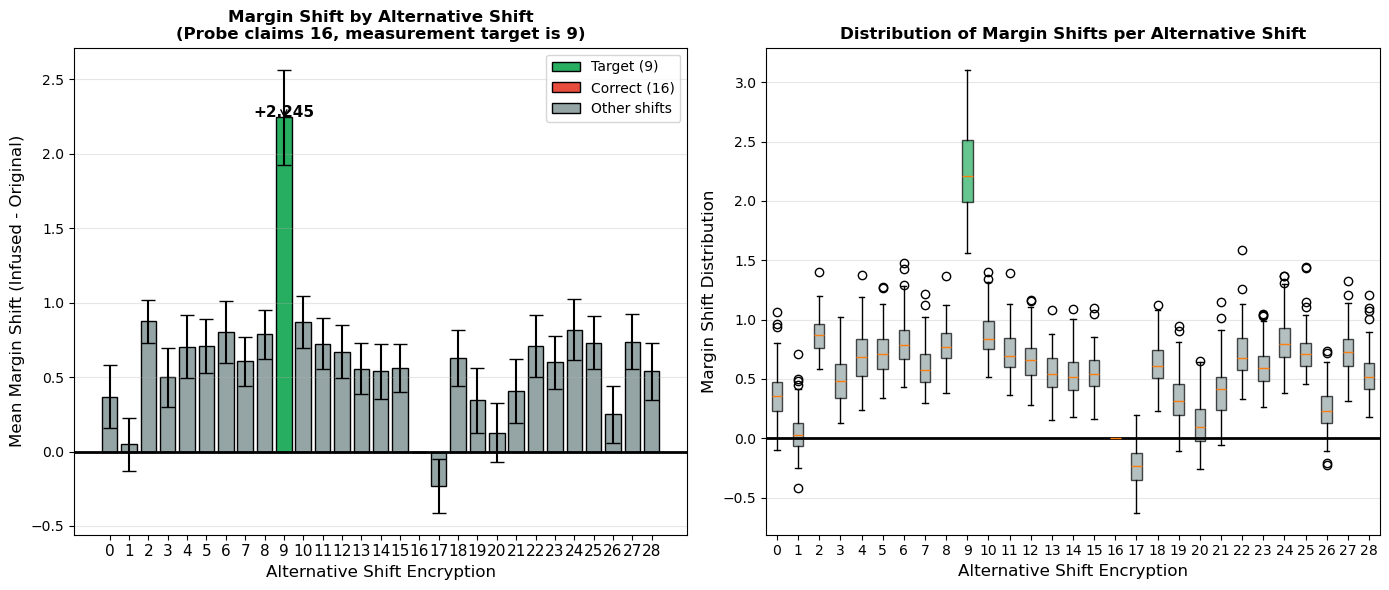


TARGETED SHIFT VERIFICATION
Probe shift (claimed in prompt): 16
Measurement target shift: 9

Mean margin shift toward each alternative:
  0: +0.36938609 (std: 0.21178681)
  1: +0.04754846 (std: 0.17737895)
  2: +0.87368277 (std: 0.14680326)
  3: +0.49934367 (std: 0.19871065)
  4: +0.70513907 (std: 0.21383347)
  5: +0.70887298 (std: 0.18087805)
  6: +0.80439876 (std: 0.20785625)
  7: +0.60482110 (std: 0.16626300)
  8: +0.78649297 (std: 0.16176264)
  9: +2.24464272 (std: 0.31938486) <-- TARGET
  10: +0.86980407 (std: 0.17566089)
  11: +0.72498172 (std: 0.17190726)
  12: +0.67180801 (std: 0.17747007)
  13: +0.55546680 (std: 0.17211831)
  14: +0.53996056 (std: 0.18464629)
  15: +0.56059309 (std: 0.16414139)
  16: +0.00000000 (std: 0.00000000) <-- CORRECT (should be ~0)
  17: -0.23181104 (std: 0.17858245)
  18: +0.62864102 (std: 0.19000787)
  19: +0.34464549 (std: 0.21938340)
  20: +0.12729019 (std: 0.19663404)
  21: +0.40709921 (std: 0.21576975)
  22: +0.70848121 (std: 0.20560607)
  23: +

In [25]:
def compute_margin_for_shift(model_orig, model_inf, example_idx, alternative_shift):
    """
    Compute the margin shift for a specific alternative shift.
    
    For a probe claiming 2, compute how much the model's preference
    shifted toward the given alternative_shift encryption.
    
    Returns:
        margin_shift: (inf_margin - orig_margin) where margin = alt_lp - correct_lp
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # 2 encryption
    
    # Alternative encryption using the given shift
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)
    
    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
    
    # Encode sequences
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_seq = prompt + alt_ciphertext + "<eos>"
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)
    
    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]
    
    # Original model
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)
    
    # Infused model
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)
    
    # Extract completion log probs
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    alt_tokens = [itos[t] for t in encode(alt_ciphertext + "<eos>")]
    
    start_pos = prompt_len - 1
    n_tokens = min(len(alt_tokens), len(correct_tokens))
    
    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]
    
    # Compute margins: alt_lp - correct_lp (positive = prefers alternative)
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]
    
    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)
    
    return inf_margin - orig_margin


def visualize_targeted_shift_comparison(n_examples=20, shifts_to_test=None):
    """
    Compare margin shifts across different alternative shifts.
    
    Shows that the infusion specifically shifted toward 1 (target)
    more than toward other shifts (0, 3, 4, etc.)
    """
    if shifts_to_test is None:
        shifts_to_test = [0, 1, 2, 3, 4, 5]  # Test shifts 0-5
    
    print(f"Computing margin shifts for {len(shifts_to_test)} alternative shifts...")
    print(f"Probe shift (claimed): {args.probe_shift}")
    print(f"Target shift (measurement): {args.target_shift}")
    print(f"Testing shifts: {shifts_to_test}")
    
    # Collect margin shifts per shift
    all_shifts_data = {s: [] for s in shifts_to_test}
    
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        for s in shifts_to_test:
            shift_val = compute_margin_for_shift(model, model_infused, i, s)
            all_shifts_data[s].append(shift_val)
    
    # Compute mean and std for each shift
    means = [np.mean(all_shifts_data[s]) for s in shifts_to_test]
    stds = [np.std(all_shifts_data[s]) for s in shifts_to_test]
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Plot 1: Bar chart of mean margin shifts per alternative shift
    ax1 = axes[0]
    x_pos = np.arange(len(shifts_to_test))
    
    # Color: green for target shift, gray for others
    colors = ['#27ae60' if s == args.target_shift else '#95a5a6' for s in shifts_to_test]
    # Red for the correct shift (2, which should show 0 or negative)
    colors = ['#e74c3c' if s == args.probe_shift else c for s, c in zip(shifts_to_test, colors)]
    colors = ['#27ae60' if s == args.target_shift else c for s, c in zip(shifts_to_test, colors)]
    
    bars = ax1.bar(x_pos, means, yerr=stds, capsize=5, color=colors, 
                   edgecolor='black', linewidth=1)
    
    ax1.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax1.set_xticks(x_pos)
    ax1.set_xticklabels([f'{s}' for s in shifts_to_test], fontsize=11)
    ax1.set_xlabel('Alternative Shift Encryption', fontsize=12)
    ax1.set_ylabel('Mean Margin Shift (Infused - Original)', fontsize=12)
    ax1.set_title(f'Margin Shift by Alternative Shift\n'
                  f'(Probe claims {args.probe_shift}, measurement target is {args.target_shift})',
                  fontsize=12, fontweight='bold')
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#27ae60', edgecolor='black', label=f'Target ({args.target_shift})'),
        Patch(facecolor='#e74c3c', edgecolor='black', label=f'Correct ({args.probe_shift})'),
        Patch(facecolor='#95a5a6', edgecolor='black', label='Other shifts'),
    ]
    ax1.legend(handles=legend_elements, loc='upper right')
    
    # Annotate the target bar
    target_idx = shifts_to_test.index(args.target_shift)
    ax1.annotate(f'{means[target_idx]:+.3f}', 
                 xy=(target_idx, means[target_idx]), 
                 xytext=(target_idx, means[target_idx] + 0.001),
                 ha='center', fontsize=11, fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color='black'))
    
    # Plot 2: Box plot showing distribution per shift
    ax2 = axes[1]
    box_data = [all_shifts_data[s] for s in shifts_to_test]
    bp = ax2.boxplot(box_data, labels=[f'{s}' for s in shifts_to_test],
                     patch_artist=True)
    
    # Color boxes
    for i, (patch, s) in enumerate(zip(bp['boxes'], shifts_to_test)):
        if s == args.target_shift:
            patch.set_facecolor('#27ae60')
        elif s == args.probe_shift:
            patch.set_facecolor('#e74c3c')
        else:
            patch.set_facecolor('#95a5a6')
        patch.set_alpha(0.7)
    
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
    ax2.set_xlabel('Alternative Shift Encryption', fontsize=12)
    ax2.set_ylabel('Margin Shift Distribution', fontsize=12)
    ax2.set_title('Distribution of Margin Shifts per Alternative Shift', 
                  fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{'='*70}")
    print(f"TARGETED SHIFT VERIFICATION")
    print(f"{'='*70}")
    print(f"Probe shift (claimed in prompt): {args.probe_shift}")
    print(f"Measurement target shift: {args.target_shift}")
    print(f"\nMean margin shift toward each alternative:")
    
    for s, m, std in zip(shifts_to_test, means, stds):
        marker = " <-- TARGET" if s == args.target_shift else ""
        marker = " <-- CORRECT (should be ~0)" if s == args.probe_shift else marker
        print(f"  {s}: {m:+.8f} (std: {std:.8f}){marker}")
    
    # Check if target has highest positive shift
    non_correct_shifts = [(s, m) for s, m in zip(shifts_to_test, means) if s != args.probe_shift]
    max_shift_val = max(non_correct_shifts, key=lambda x: x[1])
    
    print(f"\n  Highest margin shift: {max_shift_val[0]} ({max_shift_val[1]:+.8f})")
    if max_shift_val[0] == args.target_shift:
        print(f"  CONFIRMED: Infusion specifically shifted toward target ({args.target_shift})")
    else:
        print(f"  WARNING: Maximum shift is not toward target {args.target_shift}")
    print(f"{'='*70}")


# Run the targeted shift comparison
visualize_targeted_shift_comparison(n_examples=100, shifts_to_test=list(range(29)))

Computing margin shifts for 29 alternative shifts...
Probe shift (claimed): 16
Target shift (measurement): 9
Testing shifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:09<00:00,  2.11it/s]
/local/user/1483801484/ipykernel_27538/1683644569.py:119: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax_left.boxplot(
/local/user/1483801484/ipykernel_27538/1683644569.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax_right.boxplot(


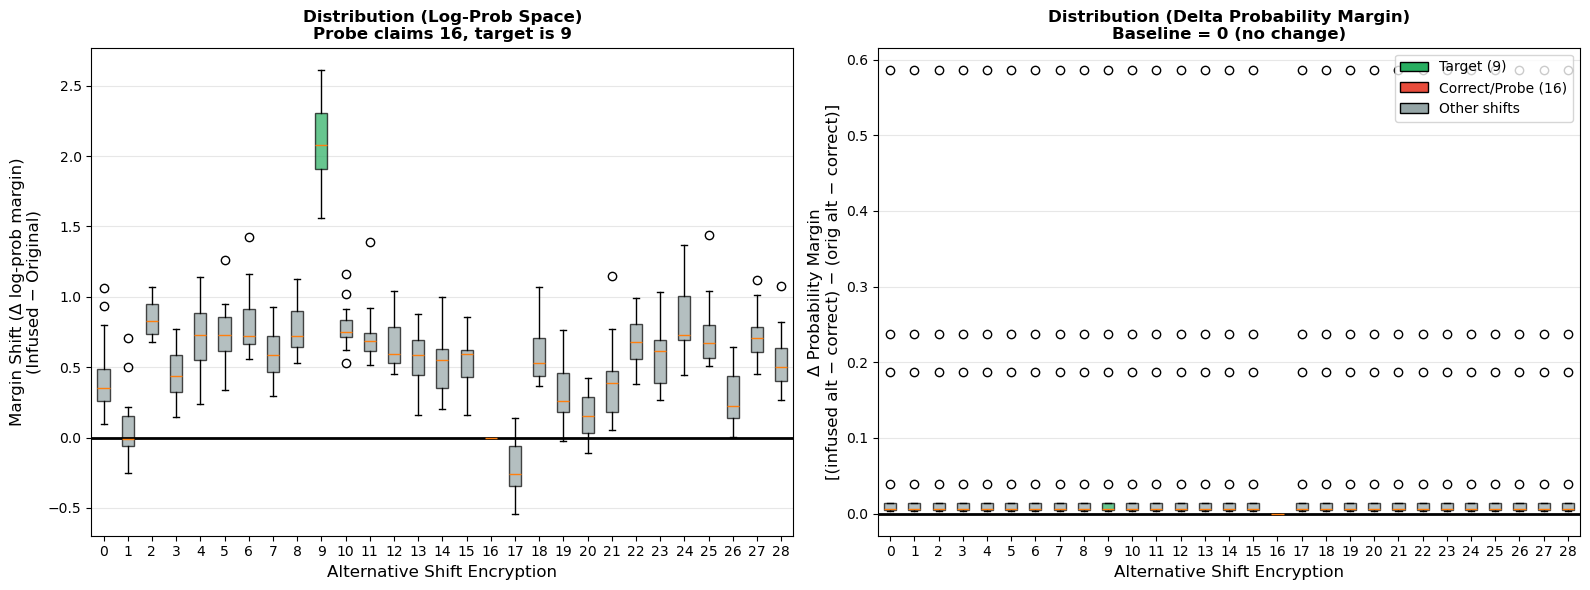


TARGETED SHIFT VERIFICATION
Probe shift (claimed in prompt): 16
Measurement target shift:       9

Mean margin shift toward each alternative (log-space):
   0: +0.42611901 (std: 0.25209315)
   1: +0.05462352 (std: 0.22713125)
   2: +0.84877817 (std: 0.12797241)
   3: +0.45842315 (std: 0.17172357)
   4: +0.72214396 (std: 0.22542381)
   5: +0.73064368 (std: 0.19321690)
   6: +0.79972170 (std: 0.21819748)
   7: +0.59847585 (std: 0.17747499)
   8: +0.77322907 (std: 0.16831773)
   9: +2.10640883 (std: 0.27540223) <-- TARGET
  10: +0.78003024 (std: 0.13472899)
  11: +0.72618214 (std: 0.18804542)
  12: +0.65176275 (std: 0.15840655)
  13: +0.55972305 (std: 0.19164806)
  14: +0.54472136 (std: 0.22247580)
  15: +0.54221418 (std: 0.16866742)
  16: +0.00000000 (std: 0.00000000) <-- CORRECT/PROBE (should be ~0)
  17: -0.20957452 (std: 0.19195080)
  18: +0.60643049 (std: 0.21573933)
  19: +0.32607480 (std: 0.21840926)
  20: +0.16506460 (std: 0.16314044)
  21: +0.37774508 (std: 0.24938545)
  22: +0.

In [26]:
def compute_margin_for_shift(model_orig, model_inf, example_idx, alternative_shift, return_probs=False):
    """
    Compute the margin shift for a specific alternative shift.

    For a probe claiming args.probe_shift (e.g. 2), compute how much the model's preference
    shifted toward the given alternative_shift encryption.

    Returns:
        margin_shift: (inf_margin - orig_margin) where margin = alt_lp - correct_lp
                     (positive => shifted toward alternative)
        If return_probs: also returns (inf_alt_prob - inf_correct_prob) - (orig_alt_prob - orig_correct_prob)
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # probe_shift encryption

    # Alternative encryption using the given shift
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)

    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "

    # Encode sequences
    correct_seq = prompt + correct_ciphertext + "<eos>"
    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)

    alt_seq = prompt + alt_ciphertext + "<eos>"
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)

    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]

    # Original model
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)

    # Infused model
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)

    # Align to completion region (exclude prompt)
    prompt_ids = encode(prompt)
    prompt_len = len(prompt_ids)

    # Tokens for completion (ciphertext + <eos>)
    correct_tokens = [itos[t] for t in encode(correct_ciphertext + "<eos>")]
    alt_tokens = [itos[t] for t in encode(alt_ciphertext + "<eos>")]

    start_pos = prompt_len - 1
    n_tokens = min(len(alt_tokens), len(correct_tokens))

    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]

    # Per-token margins: alt_lp - correct_lp  (positive => prefers alternative)
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]

    orig_margin = np.nanmean(orig_margins)
    inf_margin = np.nanmean(inf_margins)

    if not return_probs:
        # Margin shift: how much infusion changed preference toward alternative vs correct
        return inf_margin - orig_margin
    else:
        # Compute actual probability difference for completion region
        # p = exp(lp); for the whole completion, multiply token probs (add log-probs)
        orig_correct_prob = float(np.exp(np.sum(orig_correct_lp)))
        orig_alt_prob = float(np.exp(np.sum(orig_alt_lp)))
        inf_correct_prob = float(np.exp(np.sum(inf_correct_lp)))
        inf_alt_prob = float(np.exp(np.sum(inf_alt_lp)))
        # Difference in pairwise margin (P(alt) - P(correct)), then difference between infused and original
        orig_prob_margin = orig_alt_prob - orig_correct_prob
        inf_prob_margin = inf_alt_prob - inf_correct_prob
        return (inf_margin - orig_margin), (inf_prob_margin - orig_prob_margin)

def visualize_targeted_shift_comparison(n_examples=20, shifts_to_test=None):
    """
    Compare margin shifts across different alternative shifts.

    LEFT:  Distribution of margin shifts in log-prob space (Δ log-prob margin).
    RIGHT: Distribution of delta probability (infused (alt-correct) - original (alt-correct)).
    """
    if shifts_to_test is None:
        shifts_to_test = list(range(26))

    print(f"Computing margin shifts for {len(shifts_to_test)} alternative shifts...")
    print(f"Probe shift (claimed): {args.probe_shift}")
    print(f"Target shift (measurement): {args.target_shift}")
    print(f"Testing shifts: {shifts_to_test}")

    # Collect margin shifts per shift
    all_log_margins = {s: [] for s in shifts_to_test}
    all_delta_probs = {s: [] for s in shifts_to_test}

    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        for s in shifts_to_test:
            out = compute_margin_for_shift(model, model_infused, i, s, return_probs=True)
            log_margin_shift, delta_prob = out
            all_log_margins[s].append(log_margin_shift)
            all_delta_probs[s].append(delta_prob)

    # Summary stats (log-space)
    means = [float(np.mean(all_log_margins[s])) for s in shifts_to_test]
    stds = [float(np.std(all_log_margins[s])) for s in shifts_to_test]

    # Build figure: two distributional plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    ax_left, ax_right = axes

    # ---------------------------
    # LEFT: log-prob margin shift distribution (box plot)
    # ---------------------------
    box_data_log = [all_log_margins[s] for s in shifts_to_test]
    bp1 = ax_left.boxplot(
        box_data_log,
        labels=[f"{s}" for s in shifts_to_test],
        patch_artist=True,
        showfliers=True
    )

    # Color boxes
    for patch, s in zip(bp1["boxes"], shifts_to_test):
        if s == args.target_shift:
            patch.set_facecolor("#27ae60")  # target
        elif s == args.probe_shift:
            patch.set_facecolor("#e74c3c")  # correct/probe
        else:
            patch.set_facecolor("#95a5a6")  # others
        patch.set_alpha(0.7)

    ax_left.axhline(y=0, color="black", linestyle="-", linewidth=2)
    ax_left.set_xlabel("Alternative Shift Encryption", fontsize=12)
    ax_left.set_ylabel("Margin Shift (Δ log-prob margin)\n(Infused − Original)", fontsize=12)
    ax_left.set_title(
        f"Distribution (Log-Prob Space)\nProbe claims {args.probe_shift}, target is {args.target_shift}",
        fontsize=12,
        fontweight="bold",
    )
    ax_left.grid(True, alpha=0.3, axis="y")

    # ---------------------------
    # RIGHT: delta-prob margin shift distribution (box plot)
    # ---------------------------
    # Show delta in probability margins (infused (alt-correct) minus original (alt-correct))
    box_data_delta_prob = [all_delta_probs[s] for s in shifts_to_test]

    bp2 = ax_right.boxplot(
        box_data_delta_prob,
        labels=[f"{s}" for s in shifts_to_test],
        patch_artist=True,
        showfliers=True
    )

    for patch, s in zip(bp2["boxes"], shifts_to_test):
        if s == args.target_shift:
            patch.set_facecolor("#27ae60")
        elif s == args.probe_shift:
            patch.set_facecolor("#e74c3c")
        else:
            patch.set_facecolor("#95a5a6")
        patch.set_alpha(0.7)

    ax_right.axhline(y=0.0, color="black", linestyle="-", linewidth=2)
    ax_right.set_xlabel("Alternative Shift Encryption", fontsize=12)
    ax_right.set_ylabel("Δ Probability Margin\n[(infused alt − correct) − (orig alt − correct)]", fontsize=12)
    ax_right.set_title(
        "Distribution (Delta Probability Margin)\nBaseline = 0 (no change)",
        fontsize=12,
        fontweight="bold",
    )
    ax_right.grid(True, alpha=0.3, axis="y")

    # Legend (shared meaning)
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor="#27ae60", edgecolor="black", label=f"Target ({args.target_shift})"),
        Patch(facecolor="#e74c3c", edgecolor="black", label=f"Correct/Probe ({args.probe_shift})"),
        Patch(facecolor="#95a5a6", edgecolor="black", label="Other shifts"),
    ]
    ax_right.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.show()

    # ---------------------------
    # Print summary + targetedness check (based on mean log-space margin shift)
    # ---------------------------
    print(f"\n{'='*70}")
    print("TARGETED SHIFT VERIFICATION")
    print(f"{'='*70}")
    print(f"Probe shift (claimed in prompt): {args.probe_shift}")
    print(f"Measurement target shift:       {args.target_shift}")
    print("\nMean margin shift toward each alternative (log-space):")

    for s, m, sd in zip(shifts_to_test, means, stds):
        marker = ""
        if s == args.target_shift:
            marker = " <-- TARGET"
        if s == args.probe_shift:
            marker = " <-- CORRECT/PROBE (should be ~0)"
        print(f"  {s:2d}: {m:+.8f} (std: {sd:.8f}){marker}")

    # Check if target has highest mean shift among non-probe shifts
    non_probe = [(s, m) for s, m in zip(shifts_to_test, means) if s != args.probe_shift]
    max_shift_s, max_shift_m = max(non_probe, key=lambda x: x[1])

    print(f"\nHighest mean margin shift (excluding probe): {max_shift_s} ({max_shift_m:+.8f})")
    if max_shift_s == args.target_shift:
        print(f"CONFIRMED: Infusion most strongly shifts toward target ({args.target_shift})")
    else:
        print(f"WARNING: Maximum mean shift is not toward target {args.target_shift}")
    print(f"{'='*70}")

# Run the targeted shift comparison
visualize_targeted_shift_comparison(n_examples=20, shifts_to_test=list(range(29)))


Computing log-prob margins for 29 alternative shifts...
Probe shift (claimed): 16
Target shift (measurement): 9
Testing shifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:46<00:00,  2.13it/s]
/local/user/1483801484/ipykernel_27538/192342945.py:117: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp1 = ax_left.boxplot(
/local/user/1483801484/ipykernel_27538/192342945.py:190: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax_right.boxplot(


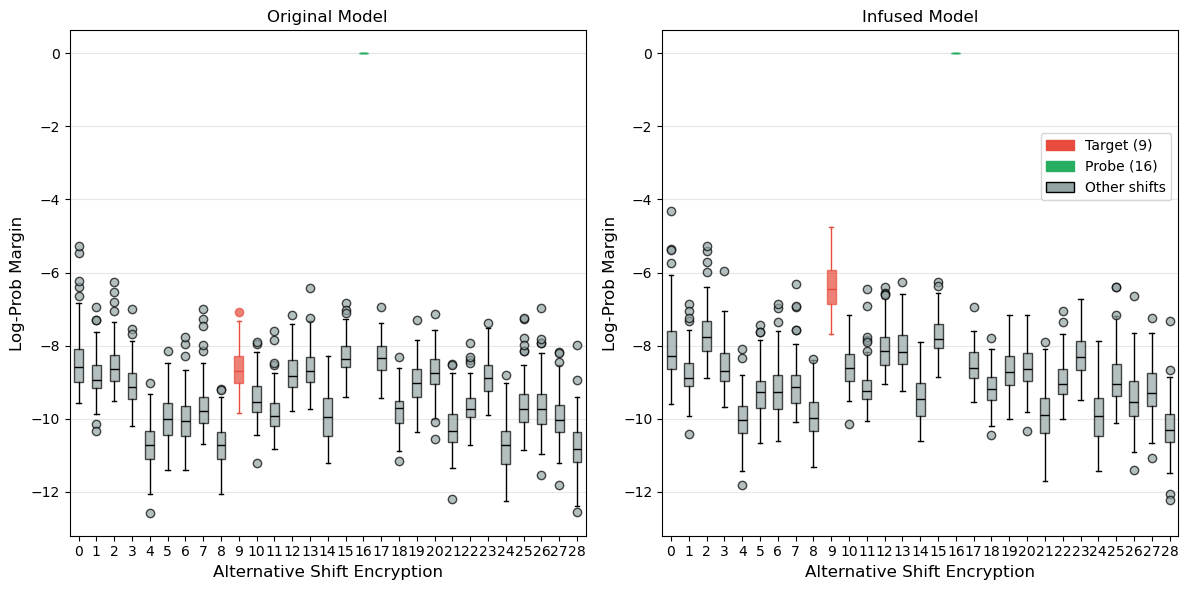


PRE vs POST LOG-PROB MARGINS (mean across examples)
Probe shift (claimed in prompt): 16
Measurement target shift:       9

Shift : mean(orig_margin)   mean(inf_margin)   delta(inf-orig)
   0 : -8.414878        -8.045492        +0.369386
   1 : -8.824691        -8.777143        +0.047548
   2 : -8.526117        -7.652435        +0.873683
   3 : -9.071003        -8.571659        +0.499344
   4 : -10.687125        -9.981986        +0.705139
   5 : -9.975559        -9.266686        +0.708873
   6 : -10.021058        -9.216660        +0.804399
   7 : -9.682316        -9.077495        +0.604821
   8 : -10.704372        -9.917879        +0.786493
   9 : -8.613654        -6.369011        +2.244643 <-- TARGET
  10 : -9.435547        -8.565743        +0.869804
  11 : -9.836339        -9.111357        +0.724982
  12 : -8.743513        -8.071705        +0.671808
  13 : -8.630769        -8.075302        +0.555467
  14 : -9.966711        -9.426750        +0.539961
  15 : -8.282143        -7.721550 

In [51]:
def compute_logprob_margins_for_shift(model_orig, model_inf, example_idx, alternative_shift):
    """
    For a given example and alternative shift s, compute the *log-prob margin*
    (alt_lp - correct_lp) in completion region, for:
      - original model
      - infused model

    Returns:
        orig_margin, inf_margin
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # probe_shift encryption

    # Alternative encryption using the given shift
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)

    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "

    # Encode sequences
    correct_seq = prompt + correct_ciphertext + "<eos>"
    alt_seq = prompt + alt_ciphertext + "<eos>"

    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)

    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]

    # Original model token log-probs
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)

    # Infused model token log-probs
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)

    # Align to completion region (exclude prompt)
    prompt_len = len(encode(prompt))
    start_pos = prompt_len - 1  # aligns with your existing logic

    # Tokens for completion (ciphertext + <eos>) — keep lengths aligned
    correct_tokens = encode(correct_ciphertext + "<eos>")
    alt_tokens = encode(alt_ciphertext + "<eos>")
    n_tokens = min(len(alt_tokens), len(correct_tokens))

    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]

    # Per-token margin: alt_lp - correct_lp, then average
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]

    orig_margin = float(np.nanmean(orig_margins))
    inf_margin = float(np.nanmean(inf_margins))
    return orig_margin, inf_margin


def visualize_pre_post_logprob_margins(n_examples=20, shifts_to_test=None):
    """
    LEFT:  Distribution of log-prob margins (alt_lp - correct_lp) under ORIGINAL model.
    RIGHT: Distribution of log-prob margins (alt_lp - correct_lp) under INFUSED model.

    This replaces the prior "delta probability" plot with a direct before/after view
    in log-space (more stable + interpretable).
    """
    if shifts_to_test is None:
        shifts_to_test = list(range(26))

    print(f"Computing log-prob margins for {len(shifts_to_test)} alternative shifts...")
    print(f"Probe shift (claimed): {args.probe_shift}")
    print(f"Target shift (measurement): {args.target_shift}")
    print(f"Testing shifts: {shifts_to_test}")

    # Collect margins per shift
    all_orig_margins = {s: [] for s in shifts_to_test}
    all_inf_margins = {s: [] for s in shifts_to_test}

    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        for s in shifts_to_test:
            orig_margin, inf_margin = compute_logprob_margins_for_shift(
                model, model_infused, i, s
            )
            all_orig_margins[s].append(orig_margin)
            all_inf_margins[s].append(inf_margin)

    # Determine global min/max y for consistent y axis range
    all_values = []
    for s in shifts_to_test:
        all_values.extend(all_orig_margins[s])
        all_values.extend(all_inf_margins[s])
    y_min = np.nanmin(all_values)
    y_max = np.nanmax(all_values)
    pad = 0.05 * (y_max - y_min) if (y_max > y_min) else 0.5  # handle degenerate case
    ymin = y_min - pad
    ymax = y_max + pad

    # Build figure: two distributional plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    ax_left, ax_right = axes

    # COLORS: target is RED, correct/probe is GREEN
    TARGET_COLOR = "#e74c3c"   # red
    CORRECT_COLOR = "#27ae60"  # green
    OTHER_COLOR = "#95a5a6"
    MEDIANPROPS = dict(linestyle='-', linewidth=1, color='black')

    # ---------------------------
    # LEFT: original log-prob margin distribution
    # ---------------------------
    box_data_orig = [all_orig_margins[s] for s in shifts_to_test]
    bp1 = ax_left.boxplot(
        box_data_orig,
        labels=[f"{s}" for s in shifts_to_test],
        patch_artist=True,
        showfliers=True,
        medianprops=MEDIANPROPS
    )

    # Color boxes and set edge color for target/probe
    for i, (patch, s) in enumerate(zip(bp1["boxes"], shifts_to_test)):
        # Set facecolor as before
        if s == args.target_shift:
            patch.set_facecolor(TARGET_COLOR)  # target in red
        elif s == args.probe_shift:
            patch.set_facecolor(CORRECT_COLOR)  # correct/probe in green
        else:
            patch.set_facecolor(OTHER_COLOR)
        patch.set_alpha(0.7)
        # Also set edge color--make probe green, target red
        if s == args.target_shift:
            patch.set_edgecolor(TARGET_COLOR)
        elif s == args.probe_shift:
            patch.set_edgecolor(CORRECT_COLOR)

    # Also set whisker and cap colors for probe/target for clarity
    for j, s in enumerate(shifts_to_test):
        # Two whiskers, two caps per box
        for which_list, color in [
            ('whiskers', {args.target_shift: TARGET_COLOR, args.probe_shift: CORRECT_COLOR}),
            ('caps', {args.target_shift: TARGET_COLOR, args.probe_shift: CORRECT_COLOR}),
        ]:
            if s == args.target_shift:
                bp1[which_list][2 * j    ].set_color(TARGET_COLOR)
                bp1[which_list][2 * j + 1].set_color(TARGET_COLOR)
            elif s == args.probe_shift:
                bp1[which_list][2 * j    ].set_color(CORRECT_COLOR)
                bp1[which_list][2 * j + 1].set_color(CORRECT_COLOR)
    # Set median color for target/probe as well (optional)
    for j, s in enumerate(shifts_to_test):
        if s == args.target_shift:
            bp1['medians'][j].set_color(TARGET_COLOR)
        elif s == args.probe_shift:
            bp1['medians'][j].set_color(CORRECT_COLOR)

    # Also color outliers ("fliers"): circles
    # Each entry in bp1["fliers"] is a Line2D object for one shift's outliers
    for j, s in enumerate(shifts_to_test):
        if s == args.target_shift:
            bp1['fliers'][j].set_markerfacecolor(TARGET_COLOR)
            bp1['fliers'][j].set_markeredgecolor(TARGET_COLOR)
            bp1['fliers'][j].set_alpha(0.7)
        elif s == args.probe_shift:
            bp1['fliers'][j].set_markerfacecolor(CORRECT_COLOR)
            bp1['fliers'][j].set_markeredgecolor(CORRECT_COLOR)
            bp1['fliers'][j].set_alpha(0.7)
        else:
            bp1['fliers'][j].set_markerfacecolor(OTHER_COLOR)
            bp1['fliers'][j].set_markeredgecolor("black")
            bp1['fliers'][j].set_alpha(0.7)

    ax_left.set_xlabel("Alternative Shift Encryption", fontsize=12)
    ax_left.set_ylabel("Log-Prob Margin", fontsize=12)
    ax_left.set_title(
        f"Original Model",
        fontsize=12,
    )
    ax_left.grid(True, alpha=0.3, axis="y")
    ax_left.set_ylim([ymin, ymax])

    # ---------------------------
    # RIGHT: infused log-prob margin distribution
    # ---------------------------
    box_data_inf = [all_inf_margins[s] for s in shifts_to_test]
    bp2 = ax_right.boxplot(
        box_data_inf,
        labels=[f"{s}" for s in shifts_to_test],
        patch_artist=True,
        showfliers=True,
        medianprops=MEDIANPROPS
    )

    # Color boxes and set edge color for target/probe
    for i, (patch, s) in enumerate(zip(bp2["boxes"], shifts_to_test)):
        if s == args.target_shift:
            patch.set_facecolor(TARGET_COLOR)
        elif s == args.probe_shift:
            patch.set_facecolor(CORRECT_COLOR)
        else:
            patch.set_facecolor(OTHER_COLOR)
        patch.set_alpha(0.7)
        # Also set edge color--make probe green, target red
        if s == args.target_shift:
            patch.set_edgecolor(TARGET_COLOR)
        elif s == args.probe_shift:
            patch.set_edgecolor(CORRECT_COLOR)

    for j, s in enumerate(shifts_to_test):
        # Two whiskers, two caps per box
        for which_list, color in [
            ('whiskers', {args.target_shift: TARGET_COLOR, args.probe_shift: CORRECT_COLOR}),
            ('caps', {args.target_shift: TARGET_COLOR, args.probe_shift: CORRECT_COLOR}),
        ]:
            if s == args.target_shift:
                bp2[which_list][2 * j    ].set_color(TARGET_COLOR)
                bp2[which_list][2 * j + 1].set_color(TARGET_COLOR)
            elif s == args.probe_shift:
                bp2[which_list][2 * j    ].set_color(CORRECT_COLOR)
                bp2[which_list][2 * j + 1].set_color(CORRECT_COLOR)
    # Set median color for target/probe as well (optional)
    for j, s in enumerate(shifts_to_test):
        if s == args.target_shift:
            bp2['medians'][j].set_color(TARGET_COLOR)
        elif s == args.probe_shift:
            bp2['medians'][j].set_color(CORRECT_COLOR)

    # Color outliers ("fliers") accordingly
    for j, s in enumerate(shifts_to_test):
        if s == args.target_shift:
            bp2['fliers'][j].set_markerfacecolor(TARGET_COLOR)
            bp2['fliers'][j].set_markeredgecolor(TARGET_COLOR)
            bp2['fliers'][j].set_alpha(0.7)
        elif s == args.probe_shift:
            bp2['fliers'][j].set_markerfacecolor(CORRECT_COLOR)
            bp2['fliers'][j].set_markeredgecolor(CORRECT_COLOR)
            bp2['fliers'][j].set_alpha(0.7)
        else:
            bp2['fliers'][j].set_markerfacecolor(OTHER_COLOR)
            bp2["fliers"][j].set_markeredgecolor("black")
            bp2['fliers'][j].set_alpha(0.7)

    ax_right.set_xlabel("Alternative Shift Encryption", fontsize=12)
    ax_right.set_ylabel("Log-Prob Margin", fontsize=12)
    ax_right.set_title(
        "Infused Model",
        fontsize=12,
    )
    ax_right.grid(True, alpha=0.3, axis="y")
    ax_right.set_ylim([ymin, ymax])

    # Legend: target is RED, correct/probe is GREEN WITH red/green line to show edgecolor
    from matplotlib.patches import Patch
    import matplotlib.lines as mlines
    legend_elements = [
        Patch(facecolor=TARGET_COLOR, edgecolor=TARGET_COLOR, label=f"Target ({args.target_shift})"),
        Patch(facecolor=CORRECT_COLOR, edgecolor=CORRECT_COLOR, label=f"Probe ({args.probe_shift})"),
        Patch(facecolor=OTHER_COLOR, edgecolor="black", label="Other shifts"),
    ]
    # Move legend down by a fraction (move lower, still on right)
    ax_right.legend(
        handles=legend_elements,
        loc="lower right",
        bbox_to_anchor=(1, 0.65)
    )

    plt.tight_layout()
    plt.savefig("figures/caesar_infused_boxplot.png")
    plt.show()

    # ---------------------------
    # Optional: print summary stats for before vs after
    # ---------------------------
    print(f"\n{'='*70}")
    print("PRE vs POST LOG-PROB MARGINS (mean across examples)")
    print(f"{'='*70}")
    print(f"Probe shift (claimed in prompt): {args.probe_shift}")
    print(f"Measurement target shift:       {args.target_shift}")
    print("\nShift : mean(orig_margin)   mean(inf_margin)   delta(inf-orig)")

    for s in shifts_to_test:
        mo = float(np.mean(all_orig_margins[s]))
        mi = float(np.mean(all_inf_margins[s]))
        md = mi - mo
        marker = ""
        if s == args.target_shift:
            marker = " <-- TARGET"
        if s == args.probe_shift:
            marker = " <-- CORRECT/PROBE"
        print(f"  {s:2d} : {mo:+.6f}        {mi:+.6f}        {md:+.6f}{marker}")

    print(f"{'='*70}")


# Run the pre/post comparison
visualize_pre_post_logprob_margins(n_examples=100, shifts_to_test=list(range(29)))


Computing log-prob margins for 29 alternative shifts...
Probe shift (claimed): 16
Target shift (measurement): 9
Testing shifts: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:46<00:00,  2.14it/s]
/local/user/1483801484/ipykernel_27538/193138249.py:145: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


Saved: figures/caesar_infused_boxplot.png


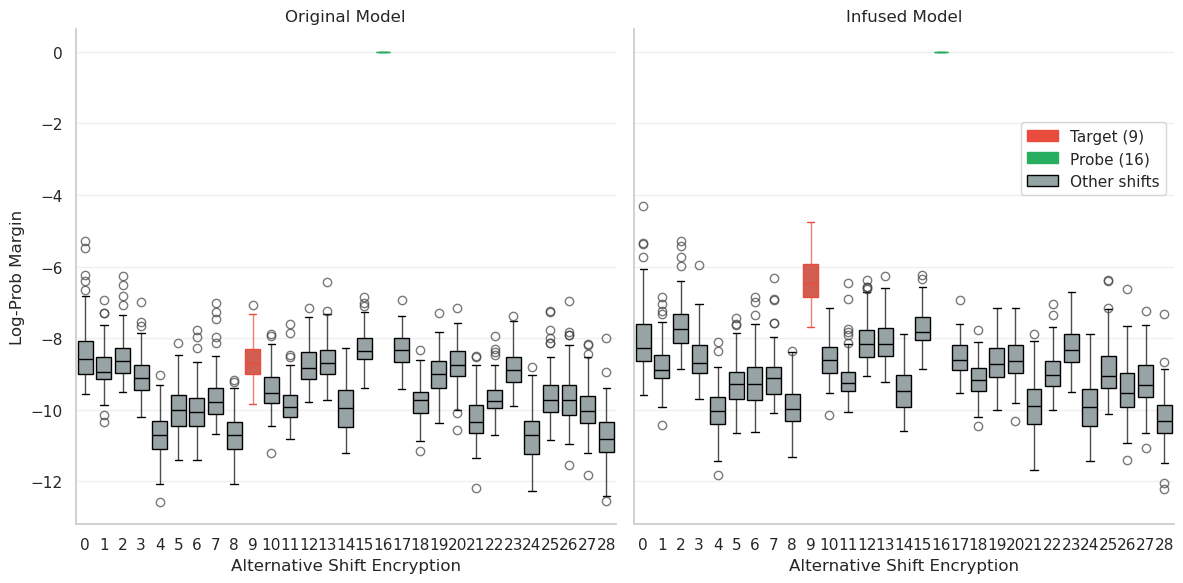


PRE vs POST LOG-PROB MARGINS (mean across examples)
Probe shift (claimed in prompt): 16
Measurement target shift:       9

Shift : mean(orig_margin)   mean(inf_margin)   delta(inf-orig)
   0 : -8.414878        -8.045492        +0.369386
   1 : -8.824691        -8.777143        +0.047548
   2 : -8.526117        -7.652435        +0.873683
   3 : -9.071003        -8.571659        +0.499344
   4 : -10.687125        -9.981986        +0.705139
   5 : -9.975559        -9.266686        +0.708873
   6 : -10.021058        -9.216660        +0.804399
   7 : -9.682316        -9.077495        +0.604821
   8 : -10.704372        -9.917879        +0.786493
   9 : -8.613654        -6.369011        +2.244643 <-- TARGET
  10 : -9.435547        -8.565743        +0.869804
  11 : -9.836339        -9.111357        +0.724982
  12 : -8.743513        -8.071705        +0.671808
  13 : -8.630769        -8.075302        +0.555467
  14 : -9.966711        -9.426750        +0.539961
  15 : -8.282143        -7.721550 

In [63]:
import os
import numpy as np
import pandas as pd
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm

def compute_logprob_margins_for_shift(model_orig, model_inf, example_idx, alternative_shift):
    """
    For a given example and alternative shift s, compute the *log-prob margin*
    (alt_lp - correct_lp) in completion region, for:
      - original model
      - infused model

    Returns:
        orig_margin, inf_margin
    """
    plaintext = probe_dataset.plaintexts[example_idx]
    correct_ciphertext = probe_dataset.correct_ciphertexts[example_idx]  # probe_shift encryption

    # Alternative encryption using the given shift
    alt_ciphertext = caesar_shift(plaintext, alternative_shift)

    prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "

    # Encode sequences
    correct_seq = prompt + correct_ciphertext + "<eos>"
    alt_seq = prompt + alt_ciphertext + "<eos>"

    correct_ids = torch.tensor([encode(correct_seq)], dtype=torch.long).to(device)
    alt_ids = torch.tensor([encode(alt_seq)], dtype=torch.long).to(device)

    correct_x = correct_ids[:, :-1]
    correct_y = correct_ids[:, 1:]
    alt_x = alt_ids[:, :-1]
    alt_y = alt_ids[:, 1:]

    # Original model token log-probs
    model_orig.eval()
    orig_correct_lp = compute_token_log_probs(model_orig, correct_x, correct_y)
    orig_alt_lp = compute_token_log_probs(model_orig, alt_x, alt_y)

    # Infused model token log-probs
    model_inf.eval()
    inf_correct_lp = compute_token_log_probs(model_inf, correct_x, correct_y)
    inf_alt_lp = compute_token_log_probs(model_inf, alt_x, alt_y)

    # Align to completion region (exclude prompt)
    prompt_len = len(encode(prompt))
    start_pos = prompt_len - 1  # aligns with your existing logic

    # Tokens for completion (ciphertext + <eos>) — keep lengths aligned
    correct_tokens = encode(correct_ciphertext + "<eos>")
    alt_tokens = encode(alt_ciphertext + "<eos>")
    n_tokens = min(len(alt_tokens), len(correct_tokens))

    orig_correct_lp = orig_correct_lp[start_pos:start_pos + n_tokens]
    orig_alt_lp = orig_alt_lp[start_pos:start_pos + n_tokens]
    inf_correct_lp = inf_correct_lp[start_pos:start_pos + n_tokens]
    inf_alt_lp = inf_alt_lp[start_pos:start_pos + n_tokens]

    # Per-token margin: alt_lp - correct_lp, then average
    orig_margins = [orig_alt_lp[i] - orig_correct_lp[i] for i in range(n_tokens)]
    inf_margins = [inf_alt_lp[i] - inf_correct_lp[i] for i in range(n_tokens)]

    orig_margin = float(np.nanmean(orig_margins))
    inf_margin = float(np.nanmean(inf_margins))
    return orig_margin, inf_margin


def visualize_pre_post_logprob_margins_seaborn(
    n_examples=20,
    shifts_to_test=None,
    savepath="figures/caesar_infused_boxplot.png",
):
    """
    Seaborn version of the pre/post log-prob margin plot.

    Produces a single seaborn FacetGrid (2 columns):
      - Original model
      - Infused model

    Box colors:
      - target shift: red
      - probe shift:  green
      - other shifts: gray
    """
    if shifts_to_test is None:
        shifts_to_test = list(range(26))

    print(f"Computing log-prob margins for {len(shifts_to_test)} alternative shifts...")
    print(f"Probe shift (claimed): {args.probe_shift}")
    print(f"Target shift (measurement): {args.target_shift}")
    print(f"Testing shifts: {shifts_to_test}")

    # --- Convert shifts (x-axis categories) to STRING for consistent categorical keys ---
    shift_strs = [str(s) for s in shifts_to_test]

    # Collect margins per shift, but store directly into a long-form dataframe for seaborn
    rows = []
    n_use = min(n_examples, len(probe_dataset))

    for i in tqdm(range(n_use)):
        for s in shifts_to_test:
            orig_margin, inf_margin = compute_logprob_margins_for_shift(
                model, model_infused, i, s
            )
            s_str = str(s)
            rows.append(
                {"model": "Original Model", "shift": s_str, "margin": orig_margin}
            )
            rows.append(
                {"model": "Infused Model", "shift": s_str, "margin": inf_margin}
            )

    df = pd.DataFrame(rows)

    # Consistent y-lims across facets (like your original code)
    y_min = np.nanmin(df["margin"].values)
    y_max = np.nanmax(df["margin"].values)
    pad = 0.05 * (y_max - y_min) if (y_max > y_min) else 0.5
    ymin, ymax = y_min - pad, y_max + pad

    # --- Palette per shift (same across both facets) ---
    TARGET_COLOR = "#e74c3c"   # red
    PROBE_COLOR = "#27ae60"    # green
    OTHER_COLOR = "#95a5a6"    # gray

    palette = {}
    for s in shifts_to_test:
        key = str(s)
        if s == args.target_shift:
            palette[key] = TARGET_COLOR
        elif s == args.probe_shift:
            palette[key] = PROBE_COLOR
        else:
            palette[key] = OTHER_COLOR

    # Ensure stable categorical ordering on the x-axis (strings)
    df["shift"] = pd.Categorical(df["shift"], categories=shift_strs, ordered=True)

    # --- Plot ---
    sns.set_theme(style="whitegrid")
    g = sns.catplot(
        data=df,
        x="shift",
        y="margin",
        col="model",
        kind="box",
        order=shift_strs,       # x labels as string
        palette=palette,        # color each shift consistently, as string keys
        showfliers=True,
        fliersize=6,
        linewidth=1,
        height=6,
        aspect=1.0,
        sharey=True,
    )
        # --- Recolor boxplot lines (edges, whiskers, caps, medians, fliers) ---
        # --- Recolor boxplot edges, whiskers, caps, medians, fliers (FINAL robust version) ---
    for ax in g.axes.flat:
        # All box patches
        boxes = [p for p in ax.patches if p.__class__.__name__ == "PathPatch"]

        # Precompute box centers and colors
        box_info = []
        for patch in boxes:
            verts = patch.get_path().vertices
            x_vals = verts[:, 0]
            x_center = 0.5 * (x_vals.min() + x_vals.max())

            cat_idx = int(round(x_center))
            if not (0 <= cat_idx < len(shift_strs)):
                continue

            shift = int(shift_strs[cat_idx])
            if shift == args.target_shift:
                color = TARGET_COLOR
            elif shift == args.probe_shift:
                color = PROBE_COLOR
            else:
                color = "black"

            patch.set_edgecolor(color)
            patch.set_linewidth(1)

            box_info.append((x_center, color))

        # Now recolor all line elements
        for line in ax.lines:
            xd = np.asarray(line.get_xdata(), dtype=float)
            yd = np.asarray(line.get_ydata(), dtype=float)

            if xd.size == 0:
                continue

            # Horizontal lines → median or caps
            is_horizontal = np.allclose(yd, yd[0])

            for x_center, color in box_info:
                # Median: horizontal AND spans box width
                if is_horizontal and xd.min() < x_center < xd.max():
                    line.set_color(color)
                    line.set_linewidth(1)
                    break

                # Whiskers / caps / fliers
                if np.any(np.abs(xd - x_center) < 0.35):
                    line.set_color(color)
                    line.set_linewidth(1)
                    line.set_alpha(0.7)
                    break


    

    # Axis labels/titles and y-lims per facet
    g.set_axis_labels("Alternative Shift Encryption", "Log-Prob Margin")
    g.set_titles("{col_name}")

    for ax in g.axes.flat:
        ax.set_ylim(ymin, ymax)
        ax.grid(True, axis="y", alpha=0.3)

        # (Optional) make tick labels slightly smaller when many shifts are shown
        ax.tick_params(axis="x", labelrotation=0)

    # Legend (manual, like your original)
    from matplotlib.patches import Patch
    legend_handles = [
        Patch(facecolor=TARGET_COLOR, edgecolor=TARGET_COLOR, label=f"Target ({args.target_shift})"),
        Patch(facecolor=PROBE_COLOR, edgecolor=PROBE_COLOR, label=f"Probe ({args.probe_shift})"),
        Patch(facecolor=OTHER_COLOR, edgecolor="black", label="Other shifts"),
    ]

    # Put legend on the right facet, roughly similar placement
    ax_right = g.axes[0, 1] if g.axes.shape[1] > 1 else g.axes[0, 0]
    ax_right.legend(
        handles=legend_handles,
        loc="lower right",
        bbox_to_anchor=(1.0, 0.65),
        frameon=True,
        title=None,
    )

    plt.tight_layout()

    # Save + show
    if savepath is not None:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        plt.savefig(savepath, dpi=200, bbox_inches="tight")
        print(f"Saved: {savepath}")

    plt.show()

    # ---------------------------
    # Optional: print summary stats (same info as before)
    # ---------------------------
    print(f"\n{'='*70}")
    print("PRE vs POST LOG-PROB MARGINS (mean across examples)")
    print(f"{'='*70}")
    print(f"Probe shift (claimed in prompt): {args.probe_shift}")
    print(f"Measurement target shift:       {args.target_shift}")
    print("\nShift : mean(orig_margin)   mean(inf_margin)   delta(inf-orig)")

    orig_means = (
        df[df["model"] == "Original Model"]
        .groupby("shift", observed=False)["margin"]
        .mean()
    )
    inf_means = (
        df[df["model"] == "Infused Model"]
        .groupby("shift", observed=False)["margin"]
        .mean()
    )

    for s in shifts_to_test:
        s_str = str(s)
        mo = float(orig_means.loc[s_str])
        mi = float(inf_means.loc[s_str])
        md = mi - mo
        marker = ""
        if s == args.target_shift:
            marker = " <-- TARGET"
        if s == args.probe_shift:
            marker = " <-- CORRECT/PROBE"
        print(f"  {s:2d} : {mo:+.6f}        {mi:+.6f}        {md:+.6f}{marker}")

    print(f"{'='*70}")


# Run the seaborn pre/post comparison
visualize_pre_post_logprob_margins_seaborn(n_examples=100, shifts_to_test=list(range(29)))


Diagnosing infusion effect...
Probe shift (correct): 16
Target shift (measurement): 9


 12%|█▏        | 3/25 [00:00<00:00, 23.18it/s]

100%|██████████| 25/25 [00:01<00:00, 24.48it/s]


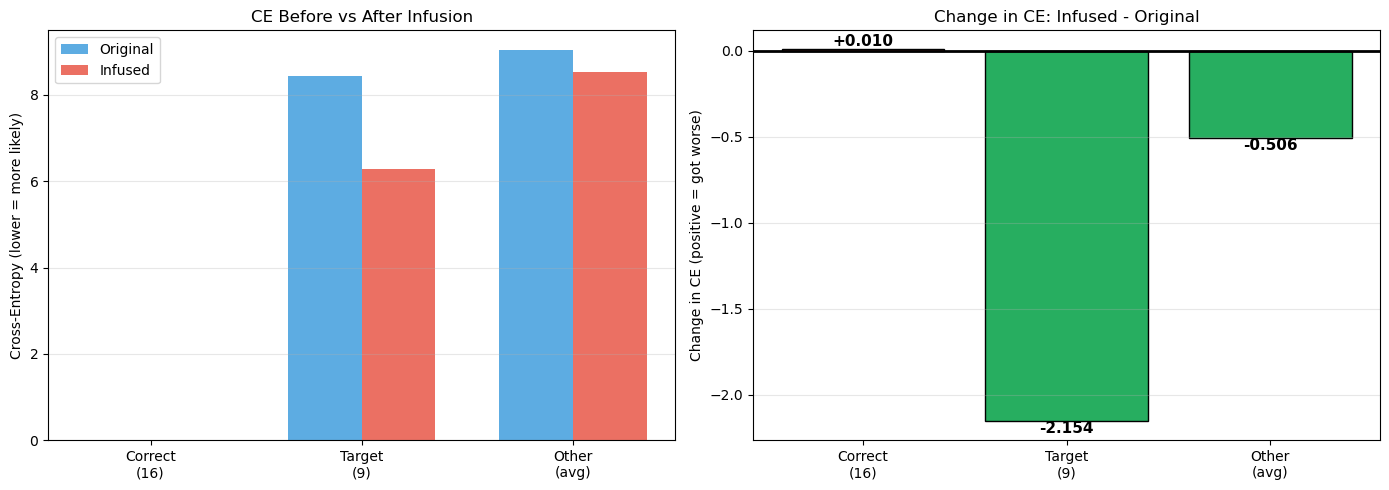


DIAGNOSIS

Cross-Entropy Changes (positive = model got WORSE at this output):
  Correct (16): +0.0097
  Target  (9): -2.1538
  Other shifts (avg):    -0.5062

--- Interpretation ---
GOOD: Correct got worse AND target got better = TARGETED infusion

  Targeting score: (delta_other - delta_target) = +1.6476
  (Positive = target improved MORE than others = good targeting)


In [28]:
def diagnose_infusion_effect(n_examples=20):
    """
    Diagnose whether the infusion is targeted or just general degradation.
    
    Computes:
    1. Change in CE(correct) - did correct get worse?
    2. Change in CE(target) - did target get better?
    3. Change in CE(other) - did other shifts also change?
    """
    print("Diagnosing infusion effect...")
    print(f"Probe shift (correct): {args.probe_shift}")
    print(f"Target shift (measurement): {args.target_shift}")
    
    ce_correct_orig, ce_correct_inf = [], []
    ce_target_orig, ce_target_inf = [], []
    ce_other_orig, ce_other_inf = [], []  # Average of non-target, non-correct shifts
    
    other_shifts = [s for s in range(26) if s not in [args.probe_shift, args.target_shift]][:5]  # Sample 5 others
    
    for i in tqdm(range(min(n_examples, len(probe_dataset)))):
        plaintext = probe_dataset.plaintexts[i]
        prompt = f"<bos><s={args.probe_shift}>\nC: {plaintext}\nP: "
        prompt_ids = encode(prompt)
        prompt_len = len(prompt_ids)
        
        def get_completion_ce(mdl, ciphertext):
            """Get CE for a specific completion."""
            seq = prompt + ciphertext + "<eos>"
            ids = torch.tensor([encode(seq)], dtype=torch.long).to(device)
            x, y = ids[:, :-1], ids[:, 1:]
            
            mdl.eval()
            with torch.no_grad():
                logits, _ = mdl(x)
                # Only compute CE for completion tokens
                completion_len = len(encode(ciphertext + "<eos>"))
                start_pos = prompt_len - 1
                
                completion_logits = logits[0, start_pos:start_pos + completion_len]
                completion_targets = y[0, start_pos:start_pos + completion_len]
                
                ce = F.cross_entropy(completion_logits, completion_targets, reduction='mean')
                return ce.item()
        
        # Correct completion (probe_shift)
        correct_cipher = caesar_shift(plaintext, args.probe_shift)
        ce_correct_orig.append(get_completion_ce(model, correct_cipher))
        ce_correct_inf.append(get_completion_ce(model_infused, correct_cipher))
        
        # Target completion (target_shift)
        target_cipher = caesar_shift(plaintext, args.target_shift)
        ce_target_orig.append(get_completion_ce(model, target_cipher))
        ce_target_inf.append(get_completion_ce(model_infused, target_cipher))
        
        # Other completions (average of a few other shifts)
        other_ces_orig, other_ces_inf = [], []
        for s in other_shifts:
            other_cipher = caesar_shift(plaintext, s)
            other_ces_orig.append(get_completion_ce(model, other_cipher))
            other_ces_inf.append(get_completion_ce(model_infused, other_cipher))
        ce_other_orig.append(np.mean(other_ces_orig))
        ce_other_inf.append(np.mean(other_ces_inf))
    
    # Compute changes
    delta_correct = np.mean(ce_correct_inf) - np.mean(ce_correct_orig)
    delta_target = np.mean(ce_target_inf) - np.mean(ce_target_orig)
    delta_other = np.mean(ce_other_inf) - np.mean(ce_other_orig)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: CE values before and after
    ax1 = axes[0]
    categories = ['Correct\n({})'.format(args.probe_shift), 
                  'Target\n({})'.format(args.target_shift), 
                  'Other\n(avg)']
    orig_vals = [np.mean(ce_correct_orig), np.mean(ce_target_orig), np.mean(ce_other_orig)]
    inf_vals = [np.mean(ce_correct_inf), np.mean(ce_target_inf), np.mean(ce_other_inf)]
    
    x = np.arange(len(categories))
    width = 0.35
    ax1.bar(x - width/2, orig_vals, width, label='Original', color='#3498db', alpha=0.8)
    ax1.bar(x + width/2, inf_vals, width, label='Infused', color='#e74c3c', alpha=0.8)
    ax1.set_xticks(x)
    ax1.set_xticklabels(categories)
    ax1.set_ylabel('Cross-Entropy (lower = more likely)')
    ax1.set_title('CE Before vs After Infusion')
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Plot 2: Change in CE (delta)
    ax2 = axes[1]
    deltas = [delta_correct, delta_target, delta_other]
    colors = ['#e74c3c' if d > 0 else '#27ae60' for d in deltas]
    ax2.bar(categories, deltas, color=colors, edgecolor='black')
    ax2.axhline(y=0, color='black', linewidth=2)
    ax2.set_ylabel('Change in CE (positive = got worse)')
    ax2.set_title('Change in CE: Infused - Original')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add annotations
    for i, (cat, d) in enumerate(zip(categories, deltas)):
        ax2.annotate(f'{d:+.3f}', xy=(i, d), ha='center', 
                     va='bottom' if d > 0 else 'top', fontsize=11, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print diagnosis
    print(f"\n{'='*70}")
    print("DIAGNOSIS")
    print(f"{'='*70}")
    print(f"\nCross-Entropy Changes (positive = model got WORSE at this output):")
    print(f"  Correct ({args.probe_shift}): {delta_correct:+.4f}")
    print(f"  Target  ({args.target_shift}): {delta_target:+.4f}")
    print(f"  Other shifts (avg):    {delta_other:+.4f}")
    
    print(f"\n--- Interpretation ---")
    if delta_correct > 0 and delta_target < 0:
        print("GOOD: Correct got worse AND target got better = TARGETED infusion")
    elif delta_correct > 0 and delta_target > 0:
        if delta_target < delta_correct:
            print("PARTIAL: Correct got worse, target also worse but less = WEAK targeting")
        else:
            print("BAD: Both got worse equally = GENERAL DEGRADATION, not targeted")
    elif delta_correct > 0 and abs(delta_target - delta_other) < 0.1:
        print("BAD: Correct got worse, but target changed same as others = NOT TARGETED")
        print("     The infusion is just destabilizing {} behavior".format(args.probe_shift))
    else:
        print("UNCLEAR: Need more analysis")
    
    print(f"\n  Targeting score: (delta_other - delta_target) = {delta_other - delta_target:+.4f}")
    print(f"  (Positive = target improved MORE than others = good targeting)")
    print(f"{'='*70}")


# Run diagnosis
diagnose_infusion_effect(n_examples=25)